In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tifffile import imread
from skimage.filters import threshold_otsu
from skimage.morphology import disk, remove_small_objects, binary_closing, binary_opening
from skimage.segmentation import clear_border, find_boundaries
from skimage.measure import label, regionprops
from skimage import io, filters, morphology, measure, segmentation, util
import seaborn as sns

In [2]:
#!/usr/bin/env python3

# -----------------------------
# IO
# -----------------------------
def read_tif_2d(path: str) -> np.ndarray:
    from PIL import Image
    import numpy as np

    im = Image.open(path)
    arr = np.array(im)

    if arr.ndim == 3:      # RGB
        arr = arr[..., :3]
        arr = arr.max(axis=-1)   # collapse to 2D

    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(f"{path}: expected 2D after conversion, got {arr.shape}")

    return arr.astype(np.float64)

# -----------------------------
# Basic geometry metrics
# -----------------------------
def area_px(mask: np.ndarray) -> int:
    return int(np.count_nonzero(mask))

def perimeter_px(mask: np.ndarray) -> float:
    # skimage perimeter is in pixels; connectivity can be adjusted if desired
    # using measure.perimeter(mask, neighborhood=8) in older versions.
    return float(measure.perimeter(mask.astype(bool)))

def rg_px(mask: np.ndarray) -> float:
    """
    Radius of gyration (px) for pixels in mask.
    Rg = sqrt(mean((x-xc)^2 + (y-yc)^2))
    """
    ys, xs = np.where(mask)
    if ys.size == 0:
        return np.nan
    cy = ys.mean()
    cx = xs.mean()
    return float(np.sqrt(np.mean((ys - cy) ** 2 + (xs - cx) ** 2)))

def overlap_px(a: np.ndarray, b: np.ndarray) -> int:
    return int(np.count_nonzero(a & b))

def union_px(a: np.ndarray, b: np.ndarray) -> int:
    return int(np.count_nonzero(a | b))

def jaccard(a: np.ndarray, b: np.ndarray) -> float:
    inter = overlap_px(a, b)
    uni = union_px(a, b)
    return float(inter / uni) if uni else np.nan


# -----------------------------
# Nucleus segmentation (ch00)
# -----------------------------
def segment_nucleus_from_ch00(
    ch00_path: str,
    sigma: float = 1.0,
    min_nucleus_size: int = 2000,
    hole_area: int = 2000,
    closing_radius: int = 8,
    opening_radius: int = 3,
    use_otsu: bool = True,
):
    """
    Otsu on smoothed ch00 + morphology + keep largest connected component.
    Returns:
      nucleus_mask (bool) or None
      debug dict with thr and intermediates
    """
    img = read_tif_2d(ch00_path).astype(np.float64)
    img_s = filters.gaussian(img, sigma=sigma, preserve_range=True)

    if use_otsu:
        thr = filters.threshold_otsu(img_s)
    else:
        # fallback: mean + 1*std (rarely needed)
        thr = img_s.mean() + img_s.std()

    mask = img_s >= thr

    if opening_radius and opening_radius > 0:
        mask = morphology.binary_opening(mask, morphology.disk(opening_radius))
    if closing_radius and closing_radius > 0:
        mask = morphology.binary_closing(mask, morphology.disk(closing_radius))

    if hole_area and hole_area > 0:
        mask = morphology.remove_small_holes(mask, area_threshold=hole_area)
    if min_nucleus_size and min_nucleus_size > 0:
        mask = morphology.remove_small_objects(mask, min_size=min_nucleus_size)

    # keep largest component
    lab = measure.label(mask)
    if lab.max() == 0:
        return None, {"thr": float(thr), "img": img, "img_s": img_s, "mask_pre_lcc": mask}

    props = measure.regionprops(lab)
    props = sorted(props, key=lambda p: p.area, reverse=True)
    lcc_label = props[0].label
    nuc = (lab == lcc_label)

    return nuc.astype(bool), {
        "thr": float(thr),
        "img": img,
        "img_s": img_s,
        "mask_pre_lcc": mask,
    }


# -----------------------------
# High-fraction domain segmentation (within nucleus)
# -----------------------------
def mean_intensity_in_mask(img2d: np.ndarray, mask: np.ndarray, sigma=1.0):
    img = img2d.astype(np.float64)
    img_s = filters.gaussian(img, sigma=sigma, preserve_range=True)
    vals = img_s[mask]
    if vals.size == 0:
        return np.nan, 0.0
    return float(vals.mean()), float(vals.sum())


def high_fraction_metrics_in_nucleus_tif(
    ch_path: str,
    nucleus_mask: np.ndarray,
    sigma_green: float = 1.0,
    sigma_high: float = 1.5,
    high_percentile: float = 80,
    min_high_size: int = 80,
    high_hole_area: int = 50,
    high_closing_radius: int = 2,
    high_opening_radius: int = 1,
):
    """
    Segment "high-fraction domain" by thresholding at P{high_percentile}
    of intensities *within nucleus*.
    Returns dict with masks, thresholds, intensity summary, and localization metric.
    """
    img = read_tif_2d(ch_path).astype(np.float64)

    green_s  = filters.gaussian(img, sigma=sigma_green, preserve_range=True)
    green_hi = filters.gaussian(img, sigma=sigma_high, preserve_range=True)

    vals = green_hi[nucleus_mask]
    if vals.size == 0:
        return None

    # use only >0 pixels to avoid percentile becoming 0
    vals_nz = vals[vals > 0]
    if vals_nz.size < 50:   # too few signal pixels -> no domain
        return {
            "raw": img,
            "green_smooth": green_s,
            "green_high_smooth": green_hi,
            "high_thr": np.nan,
            "high_mask": np.zeros_like(nucleus_mask, dtype=bool),
            "high_pixel_count": 0,
            "high_sum_intensity": 0.0,
            "high_mean_intensity": np.nan,
            "high_frac_localization": np.nan,
            "nuclear_mean_intensity": mean_intensity_in_mask(img, nucleus_mask, sigma=sigma_green)[0],
            "nuclear_sum_intensity": mean_intensity_in_mask(img, nucleus_mask, sigma=sigma_green)[1],
        }
    high_thr = np.percentile(vals_nz, high_percentile)
    high_mask = nucleus_mask & (green_hi >= high_thr)

    if high_opening_radius and high_opening_radius > 0:
        high_mask = morphology.binary_opening(high_mask, morphology.disk(high_opening_radius))
    if high_closing_radius and high_closing_radius > 0:
        high_mask = morphology.binary_closing(high_mask, morphology.disk(high_closing_radius))

    if min_high_size and min_high_size > 0:
        high_mask = morphology.remove_small_objects(high_mask, min_size=min_high_size)
    if high_hole_area and high_hole_area > 0:
        high_mask = morphology.remove_small_holes(high_mask, area_threshold=high_hole_area)

    # radial localization (intensity-weighted), normalized by a nucleus boundary radius
    ys, xs = np.where(nucleus_mask)
    cy, cx = ys.mean(), xs.mean()

    boundary = morphology.binary_dilation(nucleus_mask) ^ nucleus_mask
    by, bx = np.where(boundary)
    r_nuc = np.mean(np.sqrt((by - cy) ** 2 + (bx - cx) ** 2)) + 1e-9

    if high_mask.sum() == 0:
        high_loc = np.nan
        high_sum = 0.0
        high_mean = np.nan
        high_count = 0
    else:
        hy, hx = np.where(high_mask)
        high_int = green_s[hy, hx]
        high_rad = np.sqrt((hy - cy) ** 2 + (hx - cx) ** 2) / r_nuc
        high_loc = float(np.sum(high_rad * high_int) / (np.sum(high_int) + 1e-9))
        high_sum = float(np.sum(high_int))
        high_mean = float(np.mean(high_int))
        high_count = int(len(high_int))

    nuc_mean, nuc_sum = mean_intensity_in_mask(img, nucleus_mask, sigma=sigma_green)

    return {
        "raw": img,
        "green_smooth": green_s,
        "green_high_smooth": green_hi,
        "high_thr": float(high_thr),
        "high_mask": high_mask.astype(bool),
        "high_pixel_count": high_count,
        "high_sum_intensity": high_sum,
        "high_mean_intensity": high_mean,
        "high_frac_localization": high_loc,
        "nuclear_mean_intensity": nuc_mean,
        "nuclear_sum_intensity": nuc_sum,
    }


# -----------------------------
# Split into largest 2 components
# -----------------------------
def split_into_two_clusters_adaptive(
    mask: np.ndarray,
    min_second_frac: float = 0.25,     # a2 / (a1+a2) must be >= this
    max_area_ratio: float = 2.0,       # max(a1/a2, a2/a1) must be <= this
    min_sep_factor: float = 1.5,       # centroid_dist must be >= factor * max(eq_radius)
    connectivity: int = 2,             # 2 = 8-connected in 2D
):
    """
    Returns:
      c1, c2, meta
    where:
      - if "two clusters" criteria met: c1=largest CC, c2=2nd largest CC
      - else: c1=full mask, c2=all-False
    """
    mask = mask.astype(bool)
    lab = measure.label(mask, connectivity=connectivity)
    if lab.max() == 0:
        z = np.zeros_like(mask, dtype=bool)
        return z, z, {"mode": "empty"}

    props = sorted(measure.regionprops(lab), key=lambda p: p.area, reverse=True)
    if len(props) == 1:
        z = np.zeros_like(mask, dtype=bool)
        return mask, z, {"mode": "one_cc"}

    p1, p2 = props[0], props[1]
    a1, a2 = float(p1.area), float(p2.area)
    atot = a1 + a2

    # Similar area?
    area_ratio = (a1 / a2) if a2 > 0 else np.inf
    area_ratio = max(area_ratio, 1.0 / area_ratio)  # >= 1
    similar_area = area_ratio <= max_area_ratio

    # 2nd component not tiny?
    second_frac = a2 / atot if atot > 0 else 0.0
    big_enough = second_frac >= min_second_frac

    # “Large segregation” = centroid separation large vs component size
    # use equivalent radius from area: r = sqrt(area/pi)
    r1 = np.sqrt(a1 / np.pi)
    r2 = np.sqrt(a2 / np.pi)
    (y1, x1) = p1.centroid
    (y2, x2) = p2.centroid
    centroid_dist = float(np.sqrt((y1 - y2) ** 2 + (x1 - x2) ** 2))
    well_separated = centroid_dist >= (min_sep_factor * max(r1, r2))

    use_two = bool(similar_area and big_enough and well_separated)

    if use_two:
        c1 = (lab == p1.label)
        c2 = (lab == p2.label)
        meta = {
            "mode": "two_cc",
            "a1": a1, "a2": a2,
            "second_frac": second_frac,
            "area_ratio": area_ratio,
            "centroid_dist": centroid_dist,
            "r1": r1, "r2": r2,
        }
        return c1, c2, meta
    else:
        z = np.zeros_like(mask, dtype=bool)
        meta = {
            "mode": "merged_to_one",
            "a1": a1, "a2": a2,
            "second_frac": second_frac,
            "area_ratio": area_ratio,
            "centroid_dist": centroid_dist,
            "r1": r1, "r2": r2,
        }
        return mask, z, meta


# -----------------------------
# Plot helpers (optional)
# -----------------------------
def show_three_masks_row(bg00, nuc_mask, chr15_mask, chr11_mask, title):
    nuc_edge  = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    c15_edge  = morphology.binary_dilation(chr15_mask) ^ chr15_mask
    c11_edge  = morphology.binary_dilation(chr11_mask) ^ chr11_mask

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(bg00, cmap="gray")
    axes[0].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[0].set_title("Nucleus (ch00)")
    axes[0].axis("off")

    axes[1].imshow(bg00, cmap="gray")
    axes[1].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[1].imshow(chr15_mask.astype(float), alpha=0.35)
    axes[1].imshow(c15_edge.astype(float), alpha=0.9)
    axes[1].set_title("chr15 high-fraction (ch01)")
    axes[1].axis("off")

    axes[2].imshow(bg00, cmap="gray")
    axes[2].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[2].imshow(chr11_mask.astype(float), alpha=0.35)
    axes[2].imshow(c11_edge.astype(float), alpha=0.9)
    axes[2].set_title("chr11 high-fraction (ch02)")
    axes[2].axis("off")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_high_fraction_triptych(bg00, nuc_mask, ch_raw, high_mask,
                               title, high_percentile, blue_thr, high_thr,
                               overlay_alpha=0.45):
    nuc_edge  = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    high_edge = morphology.binary_dilation(high_mask) ^ high_mask

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(ch_raw, cmap="gray")
    axes[0].set_title("Channel (raw)")
    axes[0].axis("off")

    axes[1].imshow(bg00, cmap="gray")
    axes[1].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[1].set_title(f"Nucleus from ch00 (thr={blue_thr:.2f})")
    axes[1].axis("off")

    axes[2].imshow(ch_raw, cmap="gray")
    axes[2].imshow(high_mask.astype(float), alpha=overlay_alpha)
    axes[2].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[2].imshow(high_edge.astype(float), alpha=0.9)
    axes[2].set_title(f"High fraction ≥ P{high_percentile} (thr={high_thr:.2f})")
    axes[2].axis("off")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
def contrast_stretch(img2d, p_low=1, p_high=99.8):
    """
    Simple percentile contrast stretch to [0,1].
    Works for float/uint images. Does NOT change analysis, only display.
    """
    x = img2d.astype(np.float64)
    lo, hi = np.percentile(x[np.isfinite(x)], [p_low, p_high])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float64)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)

def plot_three_channel_row_on_raw(
    ch00_raw, ch01_raw, ch02_raw,
    nuc_mask, chr15_mask, chr11_mask,
    title="", p_low=1, p_high=99.8,
    alpha_fill=0.25
):
    """
    One row (1x3):
      left  = nucleus on ch00 raw
      mid   = chr15 domain on ch01 raw
      right = chr11 domain on ch02 raw
    Contrast is stretched for display.
    """
    # display images with contrast stretch
    d00 = contrast_stretch(ch00_raw, p_low, p_high)
    d01 = contrast_stretch(ch01_raw, p_low, p_high)
    d02 = contrast_stretch(ch02_raw, p_low, p_high)

    nuc_edge  = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    c15_edge  = morphology.binary_dilation(chr15_mask) ^ chr15_mask
    c11_edge  = morphology.binary_dilation(chr11_mask) ^ chr11_mask

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ch00
    axes[0].imshow(d00, cmap="gray")
    axes[0].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[0].set_title("Nucleus (ch00)")
    axes[0].axis("off")

    # ch01
    axes[1].imshow(d01, cmap="gray")
    axes[1].imshow(chr15_mask.astype(float), alpha=alpha_fill)
    axes[1].imshow(nuc_edge.astype(float), alpha=0.6)
    axes[1].imshow(c15_edge.astype(float), alpha=0.9)
    axes[1].set_title("chr15 high-fraction (ch01)")
    axes[1].axis("off")

    # ch02
    axes[2].imshow(d02, cmap="gray")
    axes[2].imshow(chr11_mask.astype(float), alpha=alpha_fill)
    axes[2].imshow(nuc_edge.astype(float), alpha=0.6)
    axes[2].imshow(c11_edge.astype(float), alpha=0.9)
    axes[2].set_title("chr11 high-fraction (ch02)")
    axes[2].axis("off")

    if title:
        fig.suptitle(title, fontsize=11)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
def plot_nucleus_on_raw(ch00_raw, nuc_mask, title="Nucleus (ch00)"):
    nuc_edge = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    plt.figure(figsize=(6, 6))
    plt.imshow(ch00_raw, cmap="gray")
    plt.imshow(nuc_edge.astype(float), alpha=0.9)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()
    
    
def plot_domain_on_raw(raw2d, nuc_mask, dom_mask, title="", alpha=0.35):
    nuc_edge = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    dom_edge = morphology.binary_dilation(dom_mask) ^ dom_mask

    plt.figure(figsize=(6,6))
    plt.imshow(raw2d, cmap="gray")
    plt.imshow(dom_mask.astype(float), alpha=alpha)       # filled domain (optional)
    plt.imshow(nuc_edge.astype(float), alpha=0.9)         # nucleus outline
    plt.imshow(dom_edge.astype(float), alpha=0.9)         # domain outline
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close()



In [3]:
# -----------------------------
# Main per-cell processing
# -----------------------------
def process_one_cell_with_highfraction(
    ch00_path: str,
    nuc_params=None,
    high_params_chr15=None,
    high_params_chr11=None,
    show_row_plot: bool = False,
    p_low: float = 0.5,
    p_high: float = 99.95,
    alpha_fill: float = 0.25,
    # adaptive split criteria:
    min_second_frac: float = 0.3,
    max_area_ratio: float = 1.3,   # within 30%
    min_sep_factor: float = 1.5,
):
    """
    Requires these functions already defined:
      read_tif_2d
      segment_nucleus_from_ch00
      high_fraction_metrics_in_nucleus_tif
      plot_three_channel_row_on_raw
      split_into_two_clusters_adaptive
      area_px, perimeter_px, rg_px
      overlap_px, union_px
    """
    nuc_params = nuc_params or {}
    high_params_chr15 = high_params_chr15 or {}
    high_params_chr11 = high_params_chr11 or {}

    base = os.path.basename(ch00_path).replace("_ch00_SV.tif", "")
    ch01 = ch00_path.replace("_ch00_SV.tif", "_ch01_SV.tif")  # chr15
    ch02 = ch00_path.replace("_ch00_SV.tif", "_ch02_SV.tif")  # chr11

    # -------------------
    # Nucleus
    # -------------------
    nuc, nuc_dbg = segment_nucleus_from_ch00(ch00_path, **nuc_params)
    if nuc is None or nuc.sum() == 0:
        return {"field_ch00_path": ch00_path, "field_basename": base, "error": "No nucleus"}

    # -------------------
    # Domains
    # -------------------
    chr15_out = high_fraction_metrics_in_nucleus_tif(ch01, nuc, **high_params_chr15)
    chr11_out = high_fraction_metrics_in_nucleus_tif(ch02, nuc, **high_params_chr11)

    if chr15_out is None or chr11_out is None:
        return {"field_ch00_path": ch00_path, "field_basename": base, "error": "No output for ch01/ch02"}

    chr15_mask = chr15_out["high_mask"].astype(bool)
    chr11_mask = chr11_out["high_mask"].astype(bool)

    # -------------------
    # Optional plot: ONE row (ch00/ch01/ch02) on RAW + contrast stretch
    # -------------------
    if show_row_plot:
        ch00_raw = read_tif_2d(ch00_path)
        ch01_raw = chr15_out["raw"]
        ch02_raw = chr11_out["raw"]
        plot_three_channel_row_on_raw(
            ch00_raw, ch01_raw, ch02_raw,
            nuc, chr15_mask, chr11_mask,
            title=base,
            p_low=p_low, p_high=p_high,
            alpha_fill=alpha_fill
        )

    # -------------------
    # Adaptive split into 2 clusters (or treat as 1)
    # -------------------
    split_kwargs = dict(
        min_second_frac=min_second_frac,
        max_area_ratio=max_area_ratio,
        min_sep_factor=min_sep_factor,
    )

    c15a, c15b, c15meta = split_into_two_clusters_adaptive(chr15_mask, **split_kwargs)
    c11a, c11b, c11meta = split_into_two_clusters_adaptive(chr11_mask, **split_kwargs)

    chr15_cluster_mode = c15meta.get("mode", "NA")
    chr11_cluster_mode = c11meta.get("mode", "NA")

    # -------------------
    # Geometry metrics
    # -------------------
    nucA = area_px(nuc)
    nucP = perimeter_px(nuc)
    nucPA = nucP / nucA if nucA else np.nan

    c15A = area_px(chr15_mask)
    c15P = perimeter_px(chr15_mask)
    c15PA = c15P / c15A if c15A else np.nan

    c11A = area_px(chr11_mask)
    c11P = perimeter_px(chr11_mask)
    c11PA = c11P / c11A if c11A else np.nan

    # overlap
    inter = overlap_px(chr15_mask, chr11_mask)
    uni = union_px(chr15_mask, chr11_mask)
    jac = float(inter / uni) if uni else np.nan

    # cluster metrics helper
    def cluster_pack(prefix, m1, m2):
        a1 = area_px(m1); a2 = area_px(m2)
        p1 = perimeter_px(m1); p2 = perimeter_px(m2)
        return {
            f"{prefix}_cluster1_area": a1,
            f"{prefix}_cluster2_area": a2,
            f"{prefix}_cluster1_perimeter_over_area": (p1 / a1) if a1 else np.nan,
            f"{prefix}_cluster2_perimeter_over_area": (p2 / a2) if a2 else np.nan,
            f"{prefix}_Rg_cluster1": rg_px(m1),
            f"{prefix}_Rg_cluster2": rg_px(m2),
        }

    # -------------------
    # Build output dict (ONLY now we touch `out`)
    # -------------------
    out = {
        "field_ch00_path": ch00_path,
        "field_basename": base,

        # nucleus geometry
        "nucleus_area": nucA,
        "nucleus_perimeter": nucP,
        "nucleus_perimeter_over_area": nucPA,
        "blue_thr": float(nuc_dbg.get("thr", np.nan)),

        # chr15 geometry
        "chr15_area": c15A,
        "chr15_perimeter": c15P,
        "chr15_perimeter_over_area": c15PA,
        "chr15_high_thr": float(chr15_out.get("high_thr", np.nan)),

        # chr11 geometry
        "chr11_area": c11A,
        "chr11_perimeter": c11P,
        "chr11_perimeter_over_area": c11PA,
        "chr11_high_thr": float(chr11_out.get("high_thr", np.nan)),

        # overlap
        "overlap_intersection_px": inter,
        "overlap_union_px": uni,
        "overlap_jaccard": jac,
        "overlap_over_chr15": (inter / c15A) if c15A else np.nan,
        "overlap_over_chr11": (inter / c11A) if c11A else np.nan,

        # cluster mode
        "chr15_cluster_mode": chr15_cluster_mode,
        "chr11_cluster_mode": chr11_cluster_mode,

        # (optional) split diagnostics
        "chr15_cluster_second_frac": c15meta.get("second_frac", np.nan),
        "chr15_cluster_area_ratio": c15meta.get("area_ratio", np.nan),
        "chr15_cluster_centroid_dist": c15meta.get("centroid_dist", np.nan),
        "chr11_cluster_second_frac": c11meta.get("second_frac", np.nan),
        "chr11_cluster_area_ratio": c11meta.get("area_ratio", np.nan),
        "chr11_cluster_centroid_dist": c11meta.get("centroid_dist", np.nan),

        # intensity metrics (chr15)
        "chr15_nuclear_mean_intensity": chr15_out.get("nuclear_mean_intensity", np.nan),
        "chr15_nuclear_sum_intensity": chr15_out.get("nuclear_sum_intensity", np.nan),
        "chr15_high_pixel_count": chr15_out.get("high_pixel_count", 0),
        "chr15_high_sum_intensity": chr15_out.get("high_sum_intensity", np.nan),
        "chr15_high_mean_intensity": chr15_out.get("high_mean_intensity", np.nan),
        "chr15_high_frac_localization": chr15_out.get("high_frac_localization", np.nan),

        # intensity metrics (chr11)
        "chr11_nuclear_mean_intensity": chr11_out.get("nuclear_mean_intensity", np.nan),
        "chr11_nuclear_sum_intensity": chr11_out.get("nuclear_sum_intensity", np.nan),
        "chr11_high_pixel_count": chr11_out.get("high_pixel_count", 0),
        "chr11_high_sum_intensity": chr11_out.get("high_sum_intensity", np.nan),
        "chr11_high_mean_intensity": chr11_out.get("high_mean_intensity", np.nan),
        "chr11_high_frac_localization": chr11_out.get("high_frac_localization", np.nan),
    }

    out.update(cluster_pack("chr15", c15a, c15b))
    out.update(cluster_pack("chr11", c11a, c11b))

    return out

Found 122 ch00 files
[1/122] 01302026-DNAFISH_TileScan 2_P 102_ch00_SV.tif


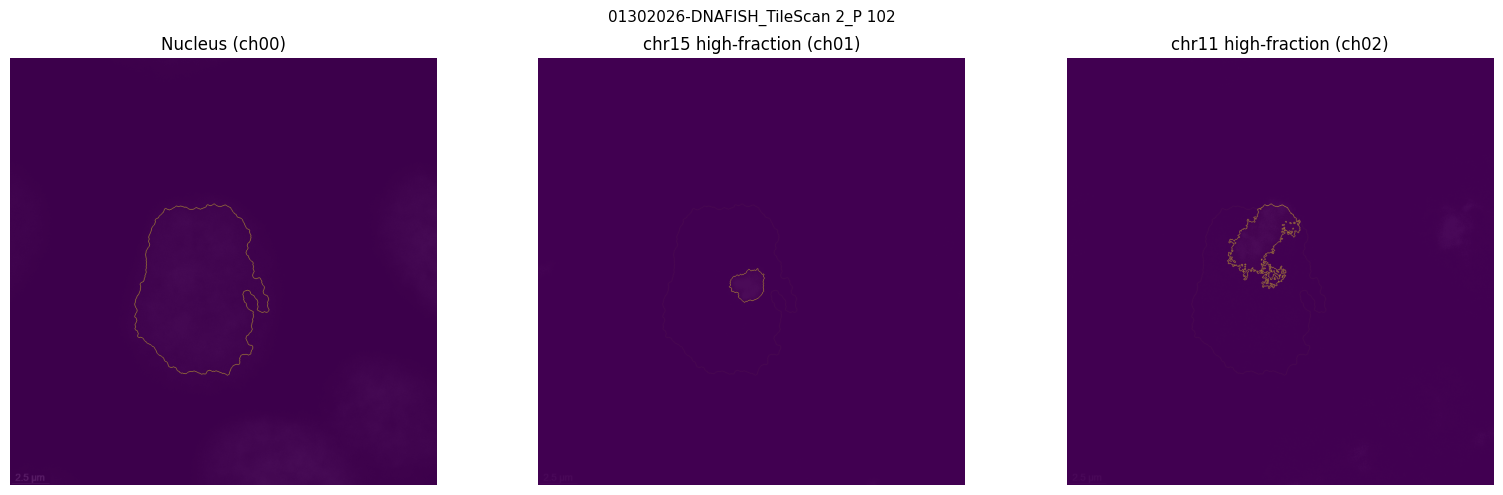

[2/122] 01302026-DNAFISH_TileScan 2_P 103_ch00_SV.tif


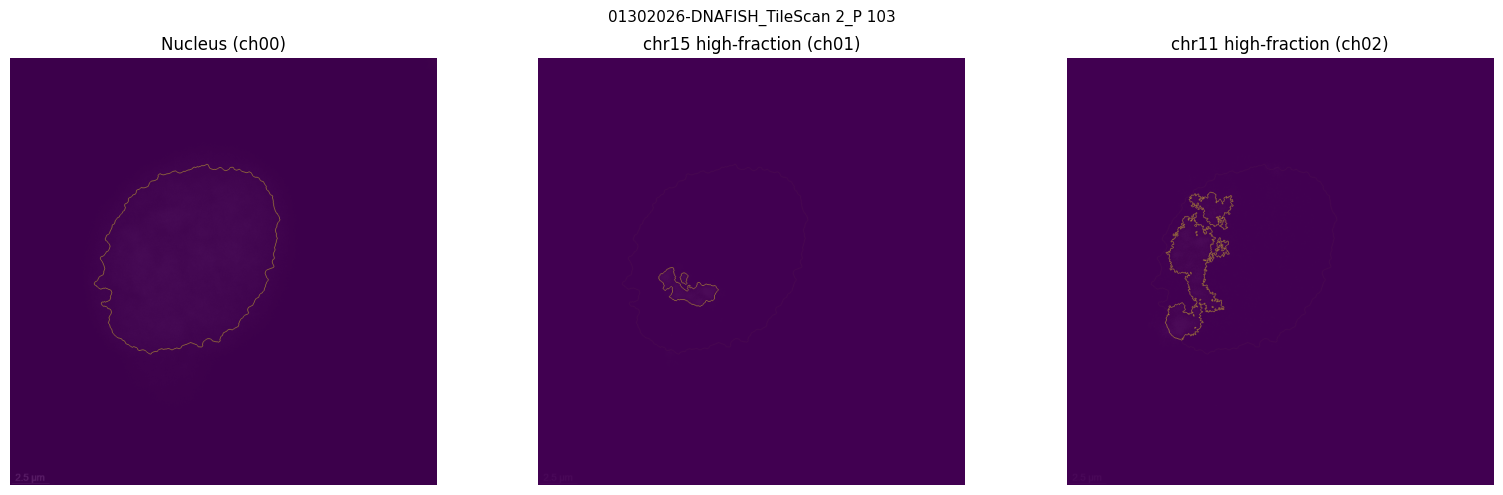

[3/122] 01302026-DNAFISH_TileScan 2_P 11_ch00_SV.tif


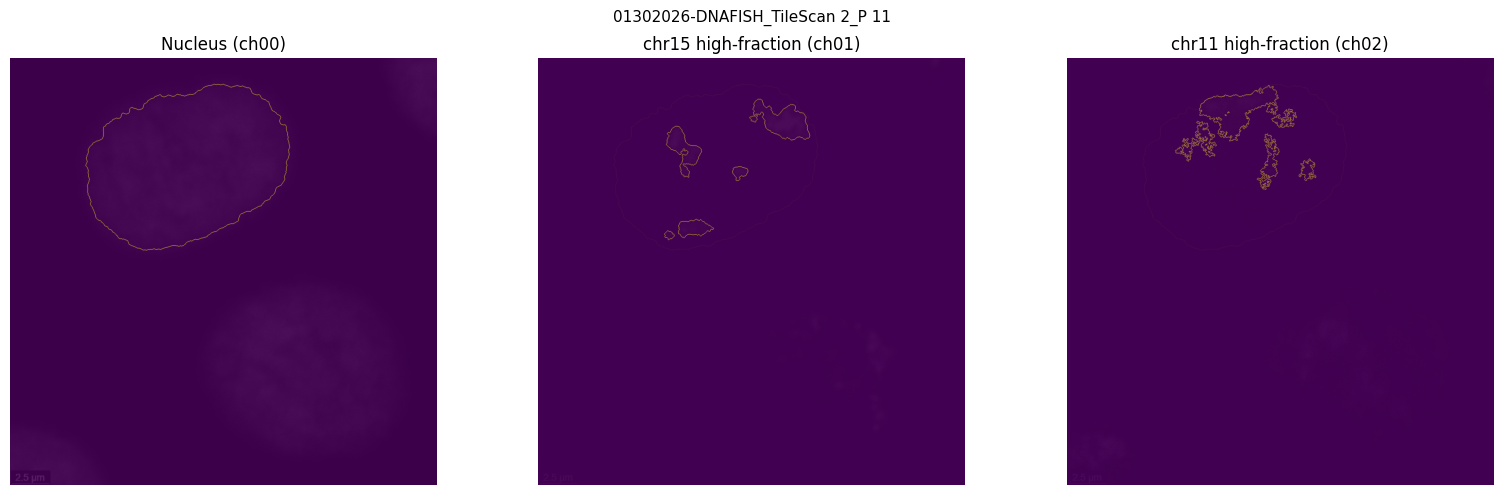

[4/122] 01302026-DNAFISH_TileScan 2_P 12_ch00_SV.tif


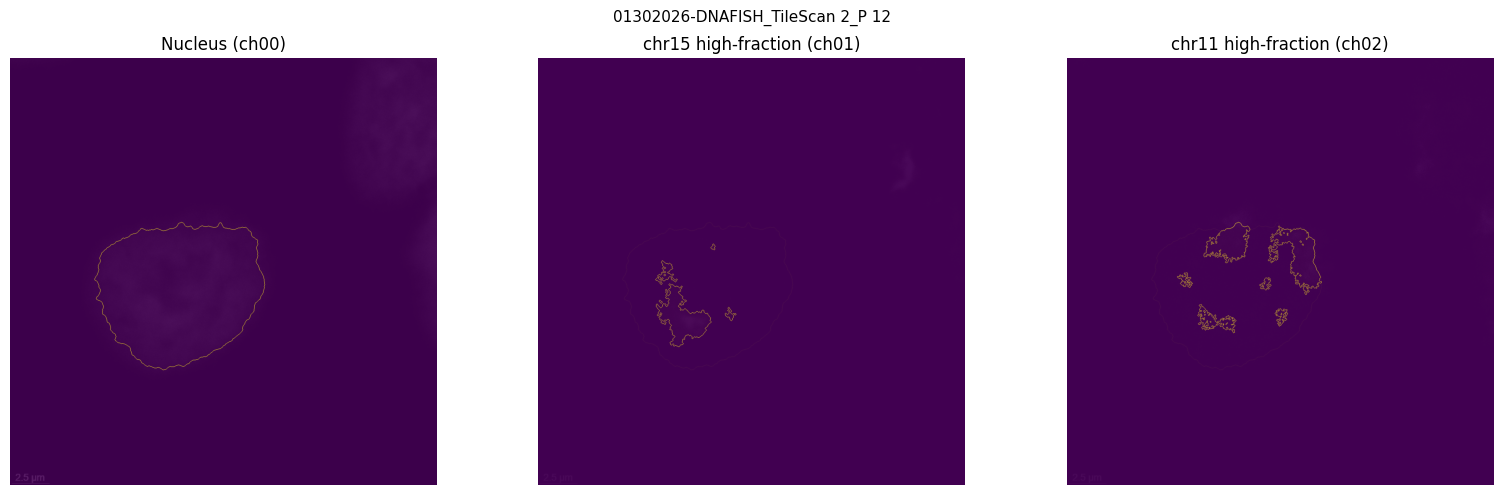

[5/122] 01302026-DNAFISH_TileScan 2_P 13_ch00_SV.tif


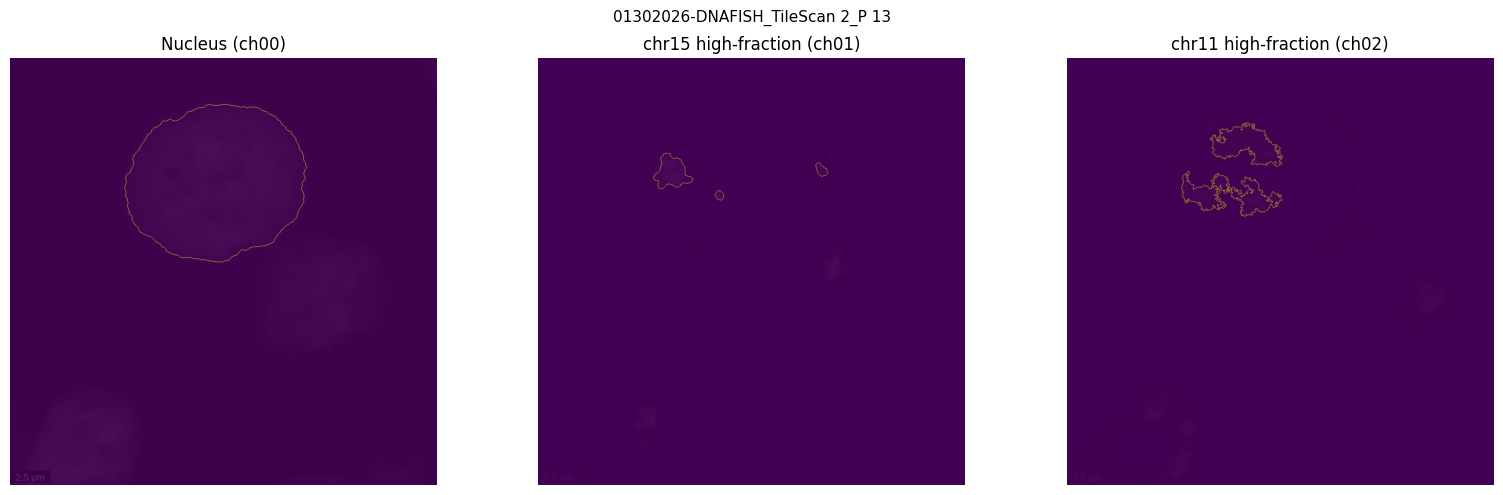

[6/122] 01302026-DNAFISH_TileScan 2_P 14_ch00_SV.tif
[7/122] 01302026-DNAFISH_TileScan 2_P 16_ch00_SV.tif
[8/122] 01302026-DNAFISH_TileScan 2_P 17_ch00_SV.tif
[9/122] 01302026-DNAFISH_TileScan 2_P 18_ch00_SV.tif
[10/122] 01302026-DNAFISH_TileScan 2_P 1_ch00_SV.tif
[11/122] 01302026-DNAFISH_TileScan 2_P 21_ch00_SV.tif
[12/122] 01302026-DNAFISH_TileScan 2_P 24_ch00_SV.tif
[13/122] 01302026-DNAFISH_TileScan 2_P 26_ch00_SV.tif
[14/122] 01302026-DNAFISH_TileScan 2_P 2_ch00_SV.tif
[15/122] 01302026-DNAFISH_TileScan 2_P 30_ch00_SV.tif
[16/122] 01302026-DNAFISH_TileScan 2_P 41_ch00_SV.tif
[17/122] 01302026-DNAFISH_TileScan 2_P 42_ch00_SV.tif
[18/122] 01302026-DNAFISH_TileScan 2_P 43_ch00_SV.tif
[19/122] 01302026-DNAFISH_TileScan 2_P 44_ch00_SV.tif
[20/122] 01302026-DNAFISH_TileScan 2_P 45_ch00_SV.tif
[21/122] 01302026-DNAFISH_TileScan 2_P 46_ch00_SV.tif
[22/122] 01302026-DNAFISH_TileScan 2_P 47_ch00_SV.tif
[23/122] 01302026-DNAFISH_TileScan 2_P 48_ch00_SV.tif
[24/122] 01302026-DNAFISH_TileScan

In [73]:
#ES stage
# ------------------------------------------------------------
# RUN (FULL)
# ------------------------------------------------------------
if __name__ == "__main__":

    folder = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/ES_chr11-488_chr15-647/"
    out_csv = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/ES_summary.csv"
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    ch00_files = sorted(glob.glob(os.path.join(folder, "*_ch00_SV.tif")))
    print(f"Found {len(ch00_files)} ch00 files")

    # -----------------------------
    # Nucleus params
    # -----------------------------
    nuc_params = dict(
        sigma=1.0,
        min_nucleus_size=2000,
        hole_area=2000,
        closing_radius=8,
        opening_radius=3,
        use_otsu=True,
    )

    # -----------------------------
    # chr15 parameters (ch01)
    # -----------------------------
    high_params_chr15 = dict(
        sigma_green=1.0,
        sigma_high=1.0,
        high_percentile=60,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=2,
        high_opening_radius=1,
    )

    # -----------------------------
    # chr11 parameters (ch02)
    # -----------------------------
    high_params_chr11 = dict(
        sigma_green=1.0,
        sigma_high=0.5,
        high_percentile=70,
        min_high_size=300,
        high_hole_area=10,
        high_closing_radius=1,
        high_opening_radius=0,
    )

    rows = []
    n_errors = 0
    n_success = 0

    N_plot = 5  # plot first 5 cells only

    for i, ch00 in enumerate(ch00_files, start=1):
        print(f"[{i}/{len(ch00_files)}] {os.path.basename(ch00)}")

        res = process_one_cell_with_highfraction(
            ch00,
            nuc_params=nuc_params,
            high_params_chr15=high_params_chr15,
            high_params_chr11=high_params_chr11,
            show_row_plot=(i <= N_plot),
            p_low=0.5,
            p_high=99.95,     # try 99.95 if still too dim
            alpha_fill=0.25,
        )

        rows.append(res)

        if "error" in res:
            n_errors += 1
        else:
            n_success += 1

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)

    print("\n-----------------------------")
    print("Processing complete.")
    print(f"Total cells: {len(ch00_files)}")
    print(f"Successful:  {n_success}")
    print(f"Errors:      {n_errors}")
    print("Saved:", out_csv)
    print("-----------------------------\n")

    print(df.head())

In [50]:
df

,field_ch00_path,field_basename,nucleus_area,nucleus_perimeter,nucleus_perimeter_over_area,blue_thr,chr15_area,chr15_perimeter,chr15_perimeter_over_area,chr15_high_thr,...,chr15_cluster1_perimeter_over_area,chr15_cluster2_perimeter_over_area,chr15_Rg_cluster1,chr15_Rg_cluster2,chr11_cluster1_area,chr11_cluster2_area,chr11_cluster1_perimeter_over_area,chr11_cluster2_perimeter_over_area,chr11_Rg_cluster1,chr11_Rg_cluster2
0,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 2_P 102,95627,1594.469263,0.016674,11.487670,6784,457.482323,0.067435,1.657268,...,0.067435,NaN,33.845215,NaN,15700,0,0.124867,NaN,60.594145,NaN
1,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 2_P 103,146218,1759.748484,0.012035,14.244710,8436,631.335137,0.074838,7.213627,...,0.074838,NaN,44.751847,NaN,24103,0,0.127823,NaN,102.322455,NaN
2,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 2_P 11,142468,1617.256059,0.011352,17.001751,21888,1942.071427,0.088728,1.087288,...,0.088728,NaN,153.268754,NaN,17370,0,0.205652,NaN,94.167331,NaN
3,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 2_P 12,106648,1416.101731,0.013278,17.001751,15016,2022.989212,0.134722,0.218580,...,0.134722,NaN,72.915056,NaN,17447,0,0.188071,NaN,115.285409,NaN
4,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 2_P 13,125417,1453.616449,0.011590,17.920765,7961,748.531096,0.094025,5.533627,...,0.094025,NaN,121.677394,NaN,19242,0,0.152973,NaN,88.052490,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 4_P 57,119471,1508.202236,0.012624,20.677806,50860,7389.699921,0.145295,0.343886,...,0.145295,NaN,126.575863,NaN,21088,0,0.183439,NaN,83.710888,NaN
118,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 4_P 6,116831,1394.503751,0.011936,18.839778,39646,5200.507607,0.131174,0.497980,...,0.131174,NaN,117.680431,NaN,28047,0,0.134895,NaN,135.616127,NaN
119,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 4_P 7,147948,1901.877380,0.012855,23.434846,45742,2921.752847,0.063875,1.961768,...,0.063875,NaN,105.341439,NaN,22608,17823,0.151661,0.089865,89.057744,61.672374
120,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 4_P 8,108903,1345.142315,0.012352,20.677806,33241,4020.364246,0.120946,0.707252,...,0.120946,NaN,114.886554,NaN,25606,0,0.169106,NaN,121.213830,NaN


Found 70 ch00 files
[1/70] 01302026-DNAFISH_TileScan 5_P 10_ch00_SV.tif


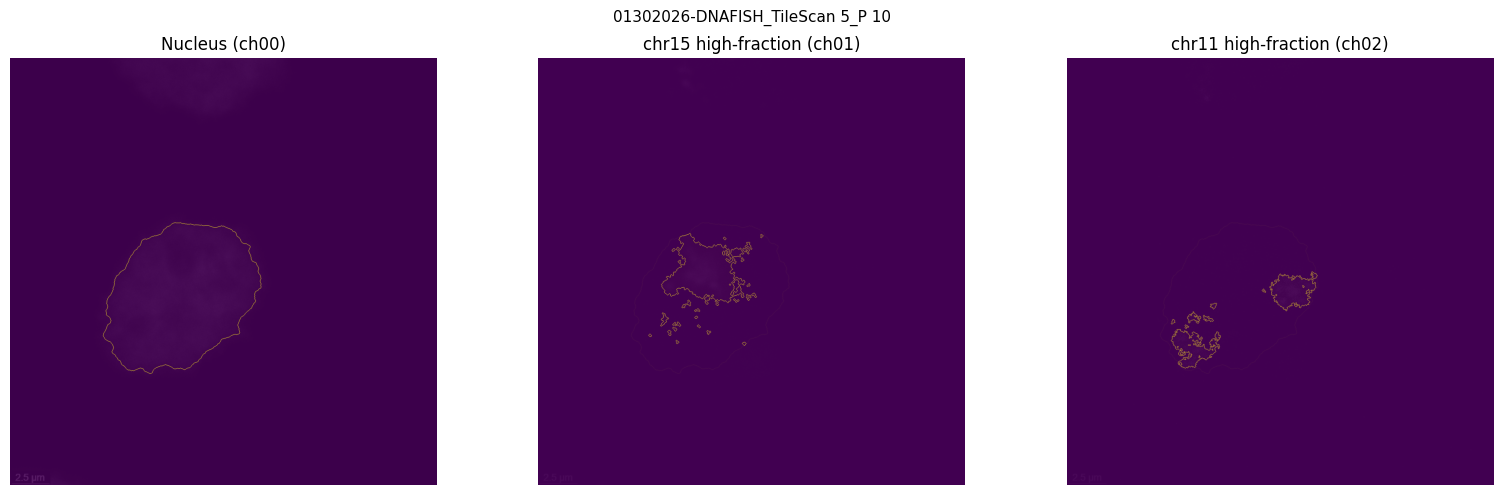

[2/70] 01302026-DNAFISH_TileScan 5_P 11_ch00_SV.tif


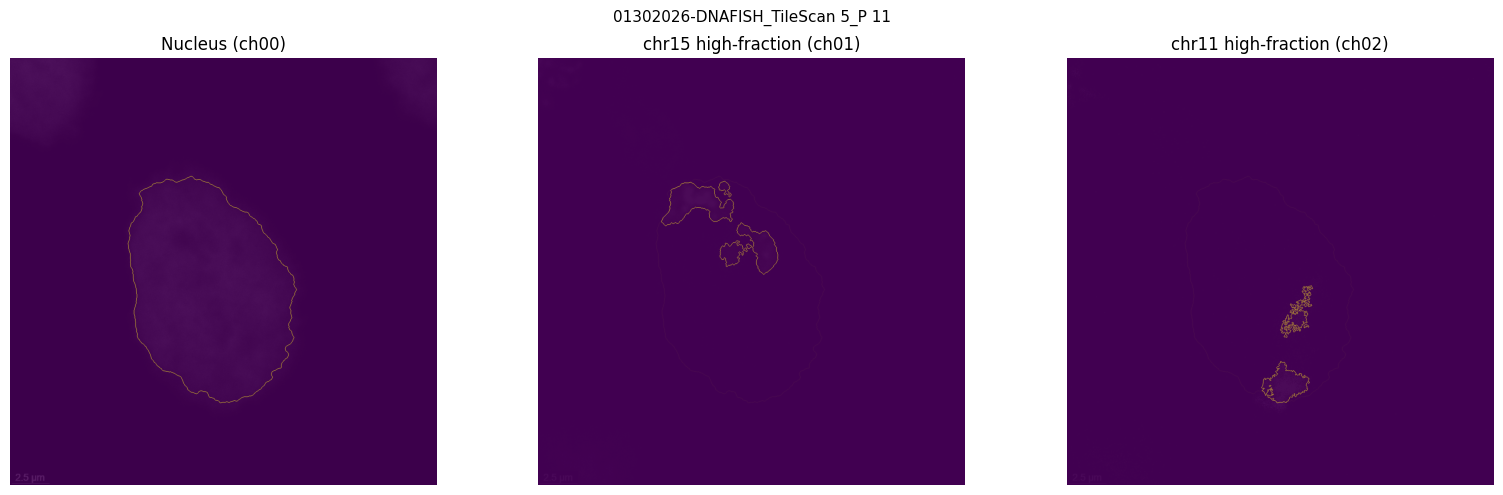

[3/70] 01302026-DNAFISH_TileScan 5_P 12_ch00_SV.tif


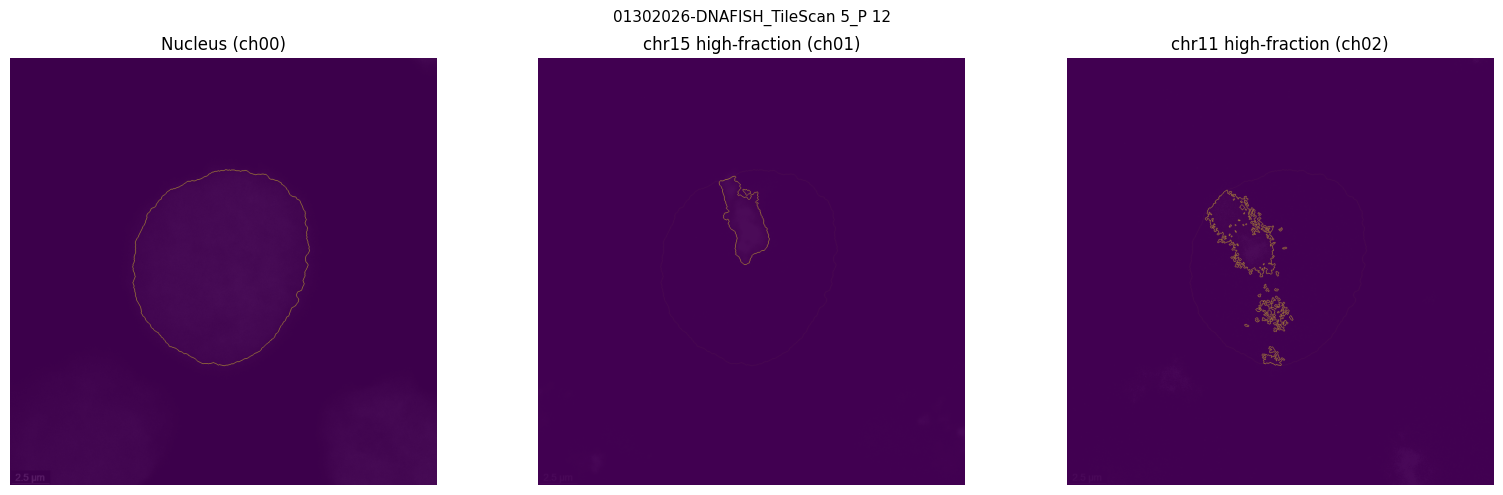

[4/70] 01302026-DNAFISH_TileScan 5_P 2_ch00_SV.tif


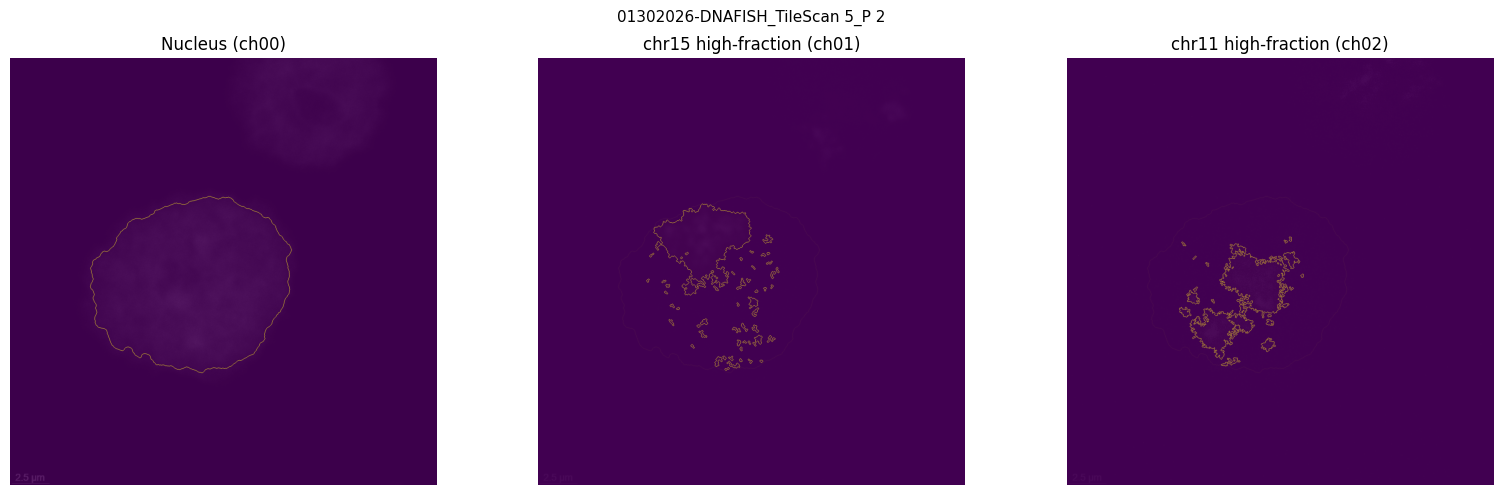

[5/70] 01302026-DNAFISH_TileScan 5_P 30_ch00_SV.tif


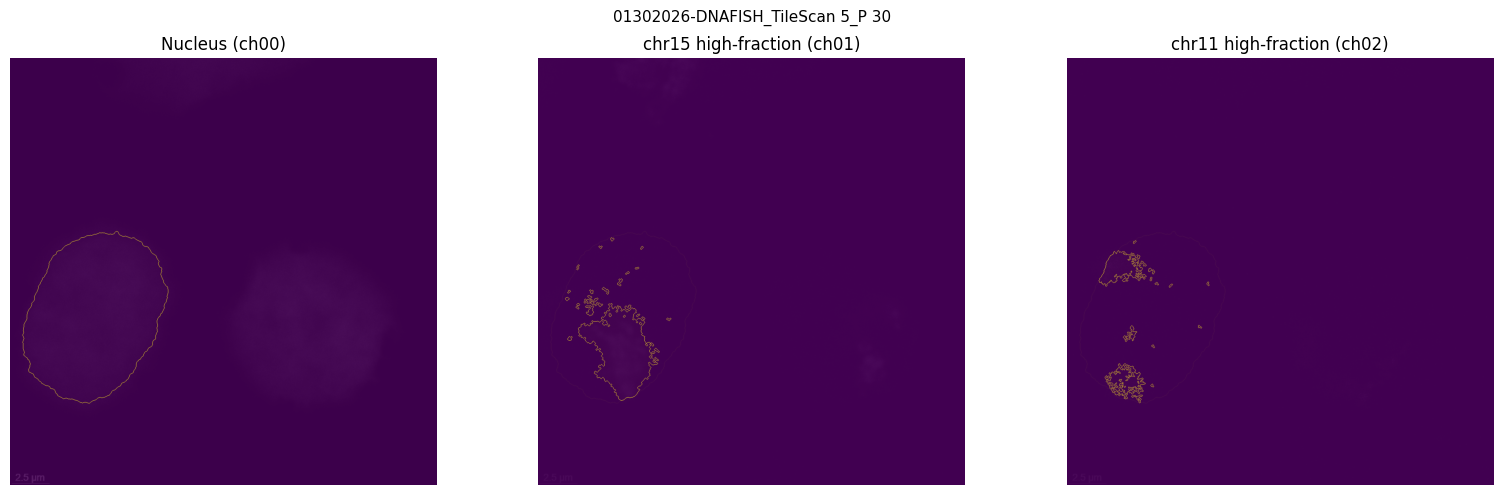

[6/70] 01302026-DNAFISH_TileScan 5_P 31_ch00_SV.tif
[7/70] 01302026-DNAFISH_TileScan 5_P 32_ch00_SV.tif
[8/70] 01302026-DNAFISH_TileScan 5_P 33_ch00_SV.tif
[9/70] 01302026-DNAFISH_TileScan 5_P 3_ch00_SV.tif
[10/70] 01302026-DNAFISH_TileScan 5_P 4_ch00_SV.tif
[11/70] 01302026-DNAFISH_TileScan 5_P 5_ch00_SV.tif
[12/70] 01302026-DNAFISH_TileScan 5_P 6 (2)_ch00_SV.tif
[13/70] 01302026-DNAFISH_TileScan 5_P 65_ch00_SV.tif
[14/70] 01302026-DNAFISH_TileScan 5_P 66_ch00_SV.tif
[15/70] 01302026-DNAFISH_TileScan 5_P 67_ch00_SV.tif
[16/70] 01302026-DNAFISH_TileScan 5_P 68_ch00_SV.tif
[17/70] 01302026-DNAFISH_TileScan 5_P 69_ch00_SV.tif
[18/70] 01302026-DNAFISH_TileScan 5_P 8_ch00_SV.tif
[19/70] 01302026-DNAFISH_TileScan 5_P 9_ch00_SV.tif
[20/70] 01302026-DNAFISH_TileScan 6_P 11_ch00_SV.tif
[21/70] 01302026-DNAFISH_TileScan 6_P 13_ch00_SV.tif
[22/70] 01302026-DNAFISH_TileScan 6_P 14_ch00_SV.tif
[23/70] 01302026-DNAFISH_TileScan 6_P 15_ch00_SV.tif
[24/70] 01302026-DNAFISH_TileScan 6_P 16_ch00_SV.tif

In [74]:
#DE stage
# ------------------------------------------------------------
# RUN (FULL)
# ------------------------------------------------------------
if __name__ == "__main__":

    folder = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/DE_chr11-488_chr15-647/"
    out_csv = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/DE_summary.csv"
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    ch00_files = sorted(glob.glob(os.path.join(folder, "*_ch00_SV.tif")))
    print(f"Found {len(ch00_files)} ch00 files")

    # -----------------------------
    # Nucleus params
    # -----------------------------
    nuc_params = dict(
        sigma=1.0,
        min_nucleus_size=2000,
        hole_area=2000,
        closing_radius=8,
        opening_radius=3,
        use_otsu=True,
    )

    # -----------------------------
    # chr15 parameters (ch01)
    # -----------------------------
    high_params_chr15 = dict(
        sigma_green=1.0,
        sigma_high=1.0,
        high_percentile=70,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=2,
        high_opening_radius=1,
    )

    # -----------------------------
    # chr11 parameters (ch02)
    # -----------------------------
    high_params_chr11 = dict(
        sigma_green=1.0,
        sigma_high=0.5,
        high_percentile=70,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=1,
        high_opening_radius=0,
    )

    rows = []
    n_errors = 0
    n_success = 0

    N_plot = 5  # plot first 5 cells only

    for i, ch00 in enumerate(ch00_files, start=1):
        print(f"[{i}/{len(ch00_files)}] {os.path.basename(ch00)}")

        res = process_one_cell_with_highfraction(
            ch00,
            nuc_params=nuc_params,
            high_params_chr15=high_params_chr15,
            high_params_chr11=high_params_chr11,
            show_row_plot=(i <= N_plot),
            p_low=0.5,
            p_high=99.95,     # try 99.95 if still too dim
            alpha_fill=0.25,
        )

        rows.append(res)

        if "error" in res:
            n_errors += 1
        else:
            n_success += 1

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)

    print("\n-----------------------------")
    print("Processing complete.")
    print(f"Total cells: {len(ch00_files)}")
    print(f"Successful:  {n_success}")
    print(f"Errors:      {n_errors}")
    print("Saved:", out_csv)
    print("-----------------------------\n")

    print(df.head())

In [55]:
df

,field_ch00_path,field_basename,nucleus_area,nucleus_perimeter,nucleus_perimeter_over_area,blue_thr,chr15_area,chr15_perimeter,chr15_perimeter_over_area,chr15_high_thr,...,chr15_cluster1_perimeter_over_area,chr15_cluster2_perimeter_over_area,chr15_Rg_cluster1,chr15_Rg_cluster2,chr11_cluster1_area,chr11_cluster2_area,chr11_cluster1_perimeter_over_area,chr11_cluster2_perimeter_over_area,chr11_Rg_cluster1,chr11_Rg_cluster2
0,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 5_P 10,96917,1343.633693,0.013864,16.082738,19025,2057.569947,0.108151,1.500449,...,0.108151,NaN,65.416601,NaN,9722,0,0.185330,NaN,139.841926,NaN
1,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 5_P 11,159233,1724.795165,0.010832,20.677806,17190,1508.346463,0.087746,9.752230,...,0.087746,NaN,99.483036,NaN,6758,0,0.169829,NaN,73.485149,NaN
2,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 5_P 12,152278,1577.297690,0.010358,16.082738,13112,732.690476,0.055879,21.940672,...,0.055879,NaN,56.875249,NaN,16058,0,0.179096,NaN,92.310757,NaN
3,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 5_P 2,152123,1658.795165,0.010904,21.596819,28893,3202.535639,0.110841,0.948455,...,0.110841,NaN,95.098641,NaN,22146,0,0.153871,NaN,88.348950,NaN
4,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 5_P 30,102754,1341.190042,0.013052,15.163724,23709,2000.942530,0.084396,2.028624,...,0.084396,NaN,72.184839,NaN,7327,0,0.267987,NaN,134.042057,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 9_P 4,104025,1342.864140,0.012909,30.786955,11069,900.780879,0.081379,12.948191,...,0.081379,NaN,63.918369,NaN,7611,0,0.203027,NaN,92.134679,NaN
66,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 9_P 5,94695,1361.248917,0.014375,24.353860,8211,1003.550432,0.122220,19.684766,...,0.122220,NaN,71.438963,NaN,8536,0,0.232915,NaN,62.131484,NaN
67,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 9_P 6,143290,1552.302741,0.010833,36.301036,10090,1202.143361,0.119142,6.825407,...,0.119142,NaN,101.427931,NaN,1195,1157,0.187548,0.166699,15.904920,14.591735
68,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 9_P 7,130306,1441.131168,0.011060,37.220050,12903,1349.126117,0.104559,39.391299,...,0.104559,NaN,70.671823,NaN,4307,0,0.140081,NaN,28.372876,NaN


Found 93 ch00 files
[1/93] 01302026-DNAFISH_TileScan 10_P 16_ch00_SV.tif


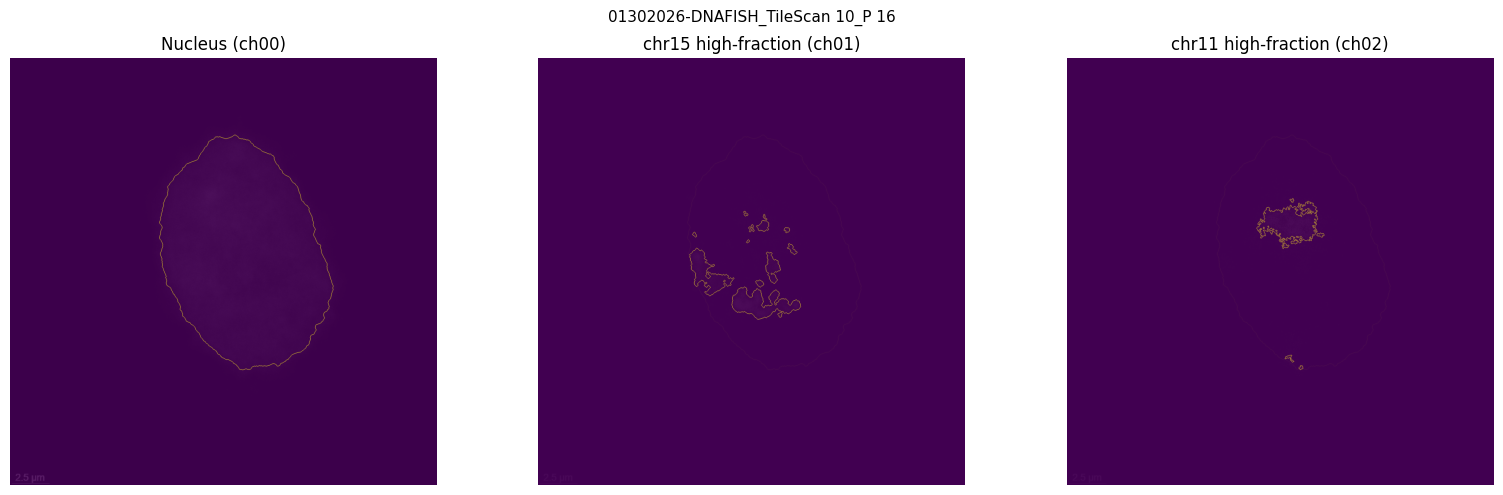

[2/93] 01302026-DNAFISH_TileScan 10_P 17_ch00_SV.tif


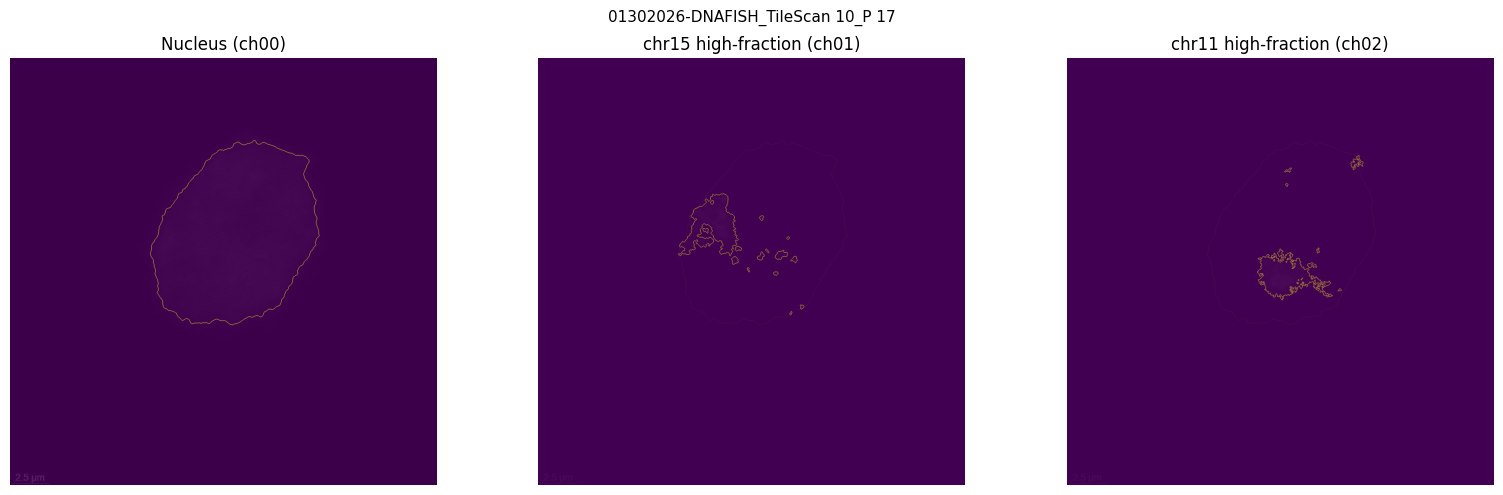

[3/93] 01302026-DNAFISH_TileScan 10_P 21_ch00_SV.tif


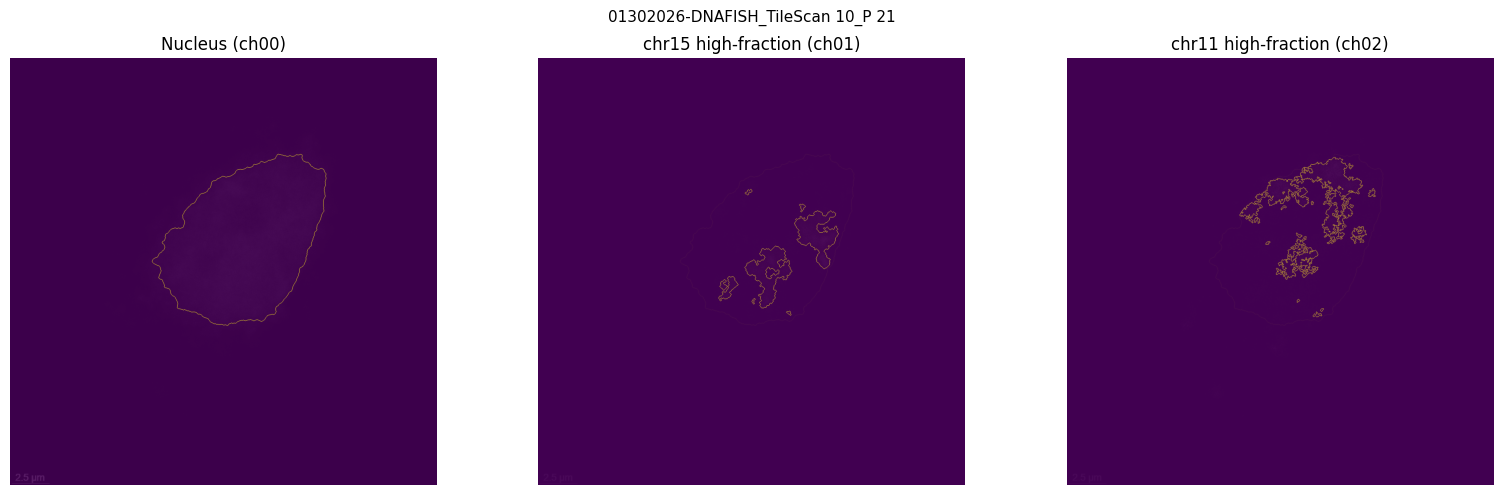

[4/93] 01302026-DNAFISH_TileScan 10_P 24_ch00_SV.tif


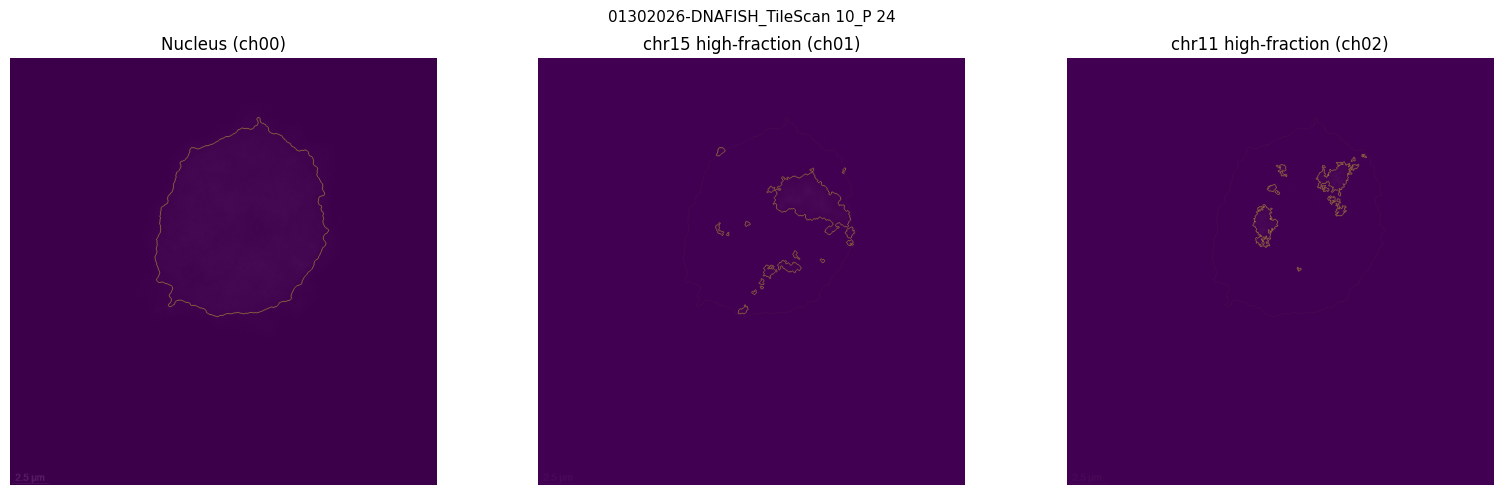

[5/93] 01302026-DNAFISH_TileScan 10_P 25_ch00_SV.tif


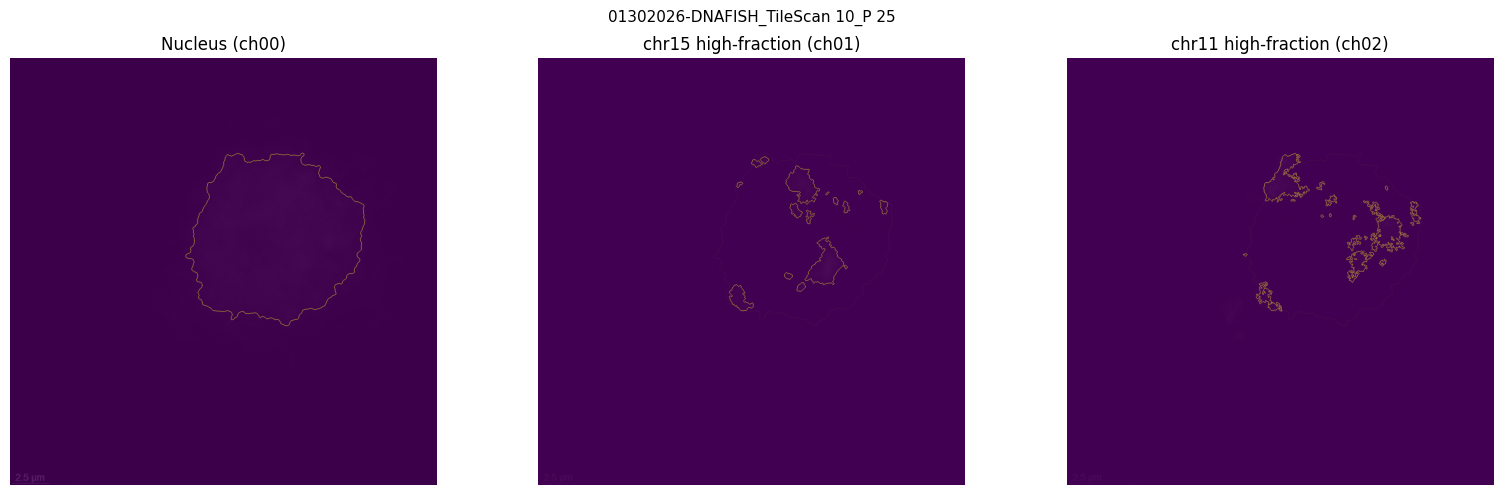

[6/93] 01302026-DNAFISH_TileScan 10_P 26_ch00_SV.tif
[7/93] 01302026-DNAFISH_TileScan 10_P 34_ch00_SV.tif
[8/93] 01302026-DNAFISH_TileScan 10_P 35_ch00_SV.tif
[9/93] 01302026-DNAFISH_TileScan 10_P 37_ch00_SV.tif
[10/93] 01302026-DNAFISH_TileScan 10_P 39_ch00_SV.tif
[11/93] 01302026-DNAFISH_TileScan 10_P 43_ch00_SV.tif
[12/93] 01302026-DNAFISH_TileScan 10_P 44_ch00_SV.tif
[13/93] 01302026-DNAFISH_TileScan 10_P 45_ch00_SV.tif
[14/93] 01302026-DNAFISH_TileScan 10_P 46_ch00_SV.tif
[15/93] 01302026-DNAFISH_TileScan 10_P 47_ch00_SV.tif
[16/93] 01302026-DNAFISH_TileScan 10_P 48_ch00_SV.tif
[17/93] 01302026-DNAFISH_TileScan 10_P 49_ch00_SV.tif
[18/93] 01302026-DNAFISH_TileScan 10_P 50_ch00_SV.tif
[19/93] 01302026-DNAFISH_TileScan 10_P 52_ch00_SV.tif
[20/93] 01302026-DNAFISH_TileScan 10_P 55_ch00_SV.tif
[21/93] 01302026-DNAFISH_TileScan 10_P 56_ch00_SV.tif
[22/93] 01302026-DNAFISH_TileScan 10_P 57_ch00_SV.tif
[23/93] 01302026-DNAFISH_TileScan 10_P 58_ch00_SV.tif
[24/93] 01302026-DNAFISH_TileSca

In [81]:
#HB stage
# ------------------------------------------------------------
# RUN (FULL)
# ------------------------------------------------------------
if __name__ == "__main__":

    folder = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/HB_chr11-488_chr15-647/"
    out_csv = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/HB_summary.csv"
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    ch00_files = sorted(glob.glob(os.path.join(folder, "*_ch00_SV.tif")))
    print(f"Found {len(ch00_files)} ch00 files")

    # -----------------------------
    # Nucleus params
    # -----------------------------
    nuc_params = dict(
        sigma=1.0,
        min_nucleus_size=2000,
        hole_area=2000,
        closing_radius=8,
        opening_radius=3,
        use_otsu=True,
    )

    # -----------------------------
    # chr15 parameters (ch01)
    # -----------------------------
    high_params_chr15 = dict(
        sigma_green=1.0,
        sigma_high=1.0,
        high_percentile=75,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=2,
        high_opening_radius=1,
    )

    # -----------------------------
    # chr11 parameters (ch02)
    # -----------------------------
    high_params_chr11 = dict(
        sigma_green=1.0,
        sigma_high=0.5,
        high_percentile=75,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=1,
        high_opening_radius=0,
    )

    rows = []
    n_errors = 0
    n_success = 0

    N_plot = 5  # plot first 5 cells only

    for i, ch00 in enumerate(ch00_files, start=1):
        print(f"[{i}/{len(ch00_files)}] {os.path.basename(ch00)}")

        res = process_one_cell_with_highfraction(
            ch00,
            nuc_params=nuc_params,
            high_params_chr15=high_params_chr15,
            high_params_chr11=high_params_chr11,
            show_row_plot=(i <= N_plot),
            p_low=0.5,
            p_high=99.95,     # try 99.95 if still too dim
            alpha_fill=0.25,
        )

        rows.append(res)

        if "error" in res:
            n_errors += 1
        else:
            n_success += 1

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)

    print("\n-----------------------------")
    print("Processing complete.")
    print(f"Total cells: {len(ch00_files)}")
    print(f"Successful:  {n_success}")
    print(f"Errors:      {n_errors}")
    print("Saved:", out_csv)
    print("-----------------------------\n")

    print(df.head())

In [58]:
df

,field_ch00_path,field_basename,nucleus_area,nucleus_perimeter,nucleus_perimeter_over_area,blue_thr,chr15_area,chr15_perimeter,chr15_perimeter_over_area,chr15_high_thr,...,chr15_cluster2_perimeter_over_area,chr15_Rg_cluster1,chr15_Rg_cluster2,chr11_cluster1_area,chr11_cluster2_area,chr11_cluster1_perimeter_over_area,chr11_cluster2_perimeter_over_area,chr11_Rg_cluster1,chr11_Rg_cluster2,error
0,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 10_P 16,165258.0,1717.464212,0.010393,16.082738,10659.0,1574.051045,0.147673,18.938571,...,NaN,88.884334,NaN,7219.0,0.0,0.175172,NaN,44.979716,NaN,NaN
1,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 10_P 17,129593.0,1540.770778,0.011889,14.244710,9342.0,1216.161651,0.130182,8.888531,...,NaN,61.505891,NaN,7769.0,0.0,0.177733,NaN,58.098028,NaN,NaN
2,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 10_P 21,112367.0,1505.758585,0.013400,13.325697,11967.0,1721.963779,0.143893,14.015279,...,0.147915,38.551572,42.009046,15065.0,0.0,0.302820,NaN,103.857685,NaN,NaN
3,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 10_P 24,142133.0,1708.452019,0.012020,13.325697,13247.0,1214.374855,0.091672,6.835954,...,NaN,74.895797,NaN,2568.0,2267.0,0.207929,0.187416,24.128360,20.897387,NaN
4,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 10_P 25,127782.0,1718.552524,0.013449,10.568656,10592.0,1507.713996,0.142345,9.283522,...,NaN,134.309994,NaN,11114.0,0.0,0.254694,NaN,154.973277,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 12_P 4,65879.0,1308.018469,0.019855,16.082738,5989.0,782.377813,0.130636,8.778163,...,NaN,46.013105,NaN,6549.0,0.0,0.193529,NaN,49.385915,NaN,NaN
89,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 12_P 6,87100.0,1508.770778,0.017322,11.487670,4981.0,714.631601,0.143472,9.202860,...,NaN,86.003909,NaN,7487.0,0.0,0.252511,NaN,77.826042,NaN,NaN
90,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 12_P 7,85949.0,1317.775829,0.015332,12.406683,5227.0,697.862048,0.133511,62.574415,...,NaN,42.239399,NaN,8940.0,0.0,0.311990,NaN,87.295243,NaN,NaN
91,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,01302026-DNAFISH_TileScan 12_P 8,111397.0,1604.327127,0.014402,13.325697,11175.0,1649.809450,0.147634,10.946254,...,NaN,88.677063,NaN,9258.0,0.0,0.189348,NaN,66.116715,NaN,NaN


Found 26 ch00 files
[1/26] 021226-DNAFISH_TileScan 2_P 4_ch00_SV.tif


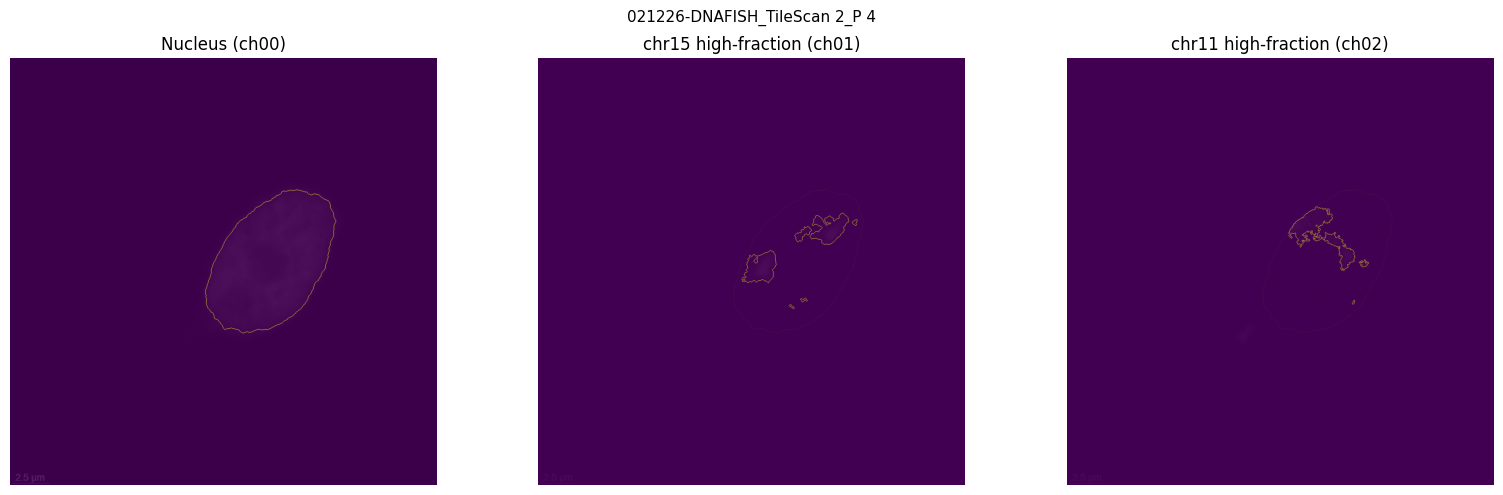

[2/26] 021226-DNAFISH_TileScan 3_P 10_ch00_SV.tif


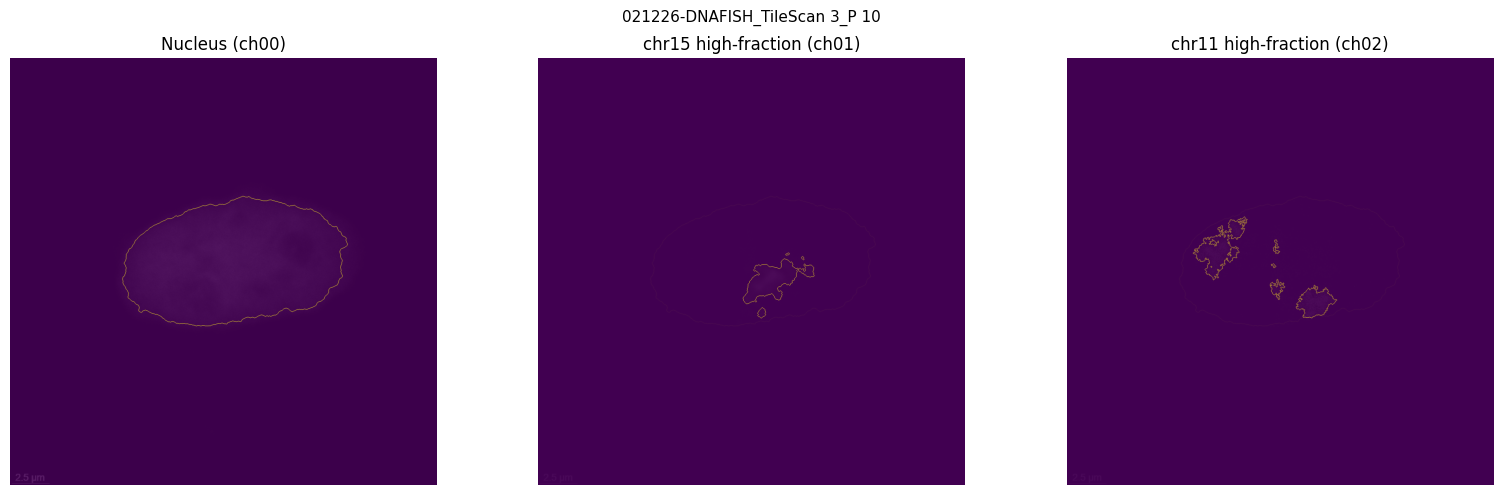

[3/26] 021226-DNAFISH_TileScan 3_P 11_ch00_SV.tif


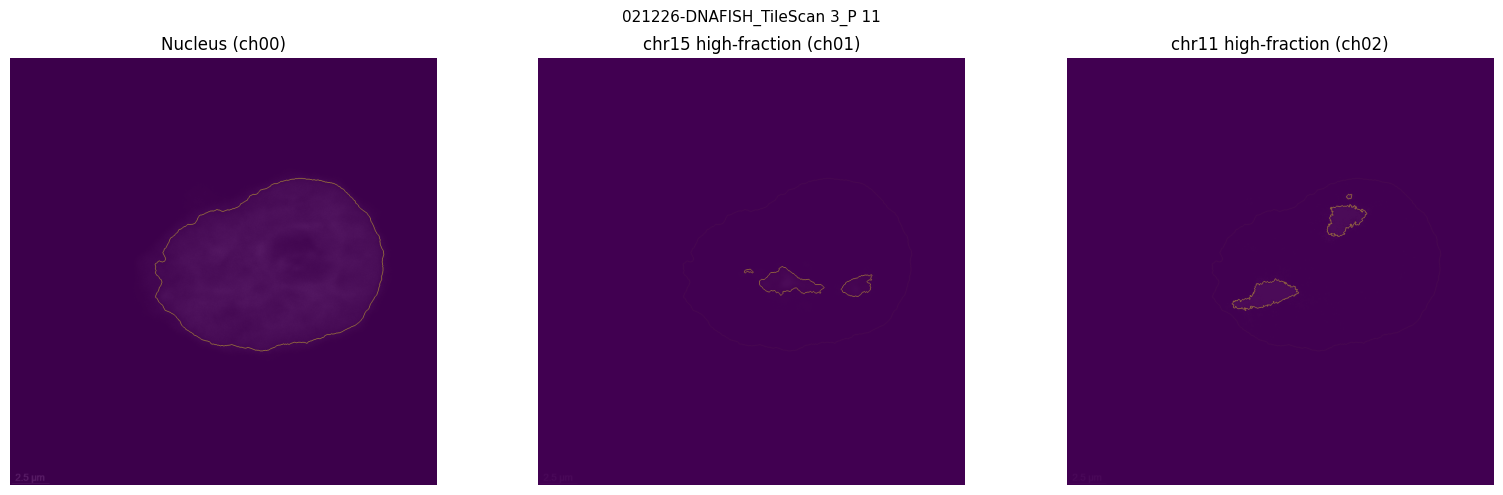

[4/26] 021226-DNAFISH_TileScan 3_P 12_ch00_SV.tif


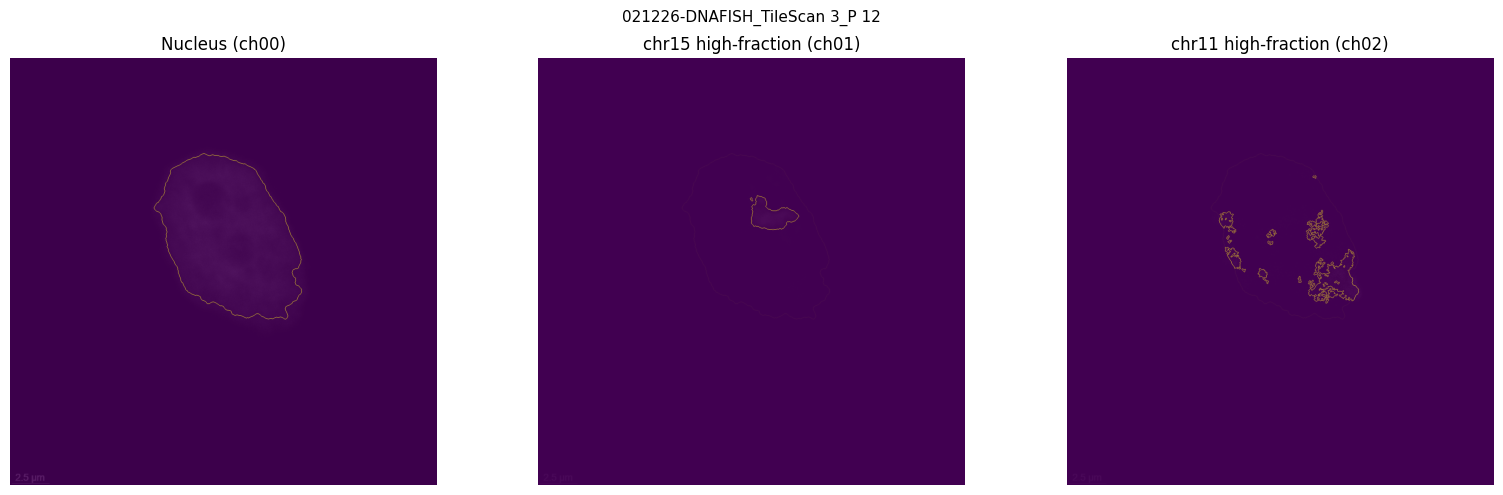

[5/26] 021226-DNAFISH_TileScan 3_P 2_ch00_SV.tif


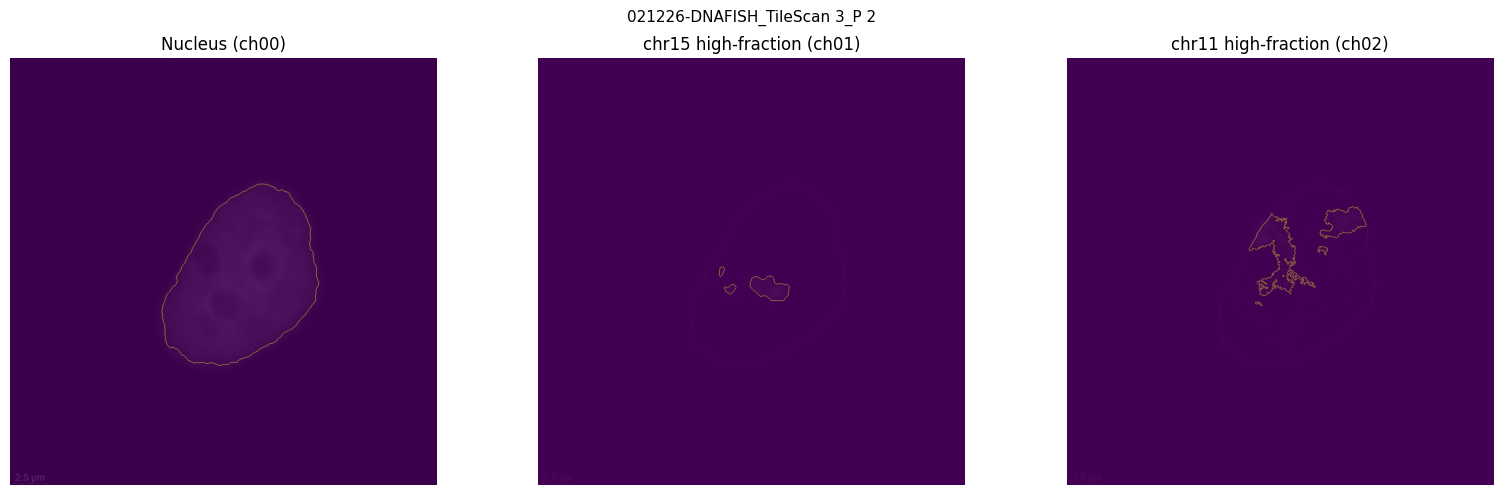

[6/26] 021226-DNAFISH_TileScan 3_P 3_ch00_SV.tif
[7/26] 021226-DNAFISH_TileScan 3_P 4_ch00_SV.tif
[8/26] 021226-DNAFISH_TileScan 3_P 5_ch00_SV.tif
[9/26] 021226-DNAFISH_TileScan 3_P 7_ch00_SV.tif
[10/26] 021226-DNAFISH_TileScan 3_P 8_ch00_SV.tif
[11/26] 021226-DNAFISH_TileScan 3_P 9_ch00_SV.tif
[12/26] 021226-DNAFISH_TileScan 4_P 10_ch00_SV.tif
[13/26] 021226-DNAFISH_TileScan 4_P 11_ch00_SV.tif
[14/26] 021226-DNAFISH_TileScan 4_P 12_ch00_SV.tif
[15/26] 021226-DNAFISH_TileScan 4_P 14_ch00_SV.tif
[16/26] 021226-DNAFISH_TileScan 4_P 1_ch00_SV.tif
[17/26] 021226-DNAFISH_TileScan 4_P 3_ch00_SV.tif
[18/26] 021226-DNAFISH_TileScan 4_P 5_ch00_SV.tif
[19/26] 021226-DNAFISH_TileScan 4_P 7_ch00_SV.tif
[20/26] 021226-DNAFISH_TileScan 4_P 8_ch00_SV.tif
[21/26] 021226-DNAFISH_TileScan 4_P 9_ch00_SV.tif
[22/26] 021226-DNAFISH_TileScan 5_P 1_ch00_SV.tif
[23/26] 021226-DNAFISH_TileScan 5_P 2_ch00_SV.tif
[24/26] 021226-DNAFISH_TileScan 5_P 3_ch00_SV.tif
[25/26] 021226-DNAFISH_TileScan 5_P 4_ch00_SV.tif


In [4]:
#iHep stage
# ------------------------------------------------------------
# RUN (FULL)
# ------------------------------------------------------------
if __name__ == "__main__":

    folder = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/iHep_chr11-488_chr15-647/"
    out_csv = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/iHep_summary.csv"
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    ch00_files = sorted(glob.glob(os.path.join(folder, "*_ch00_SV.tif")))
    print(f"Found {len(ch00_files)} ch00 files")

    # -----------------------------
    # Nucleus params
    # -----------------------------
    nuc_params = dict(
        sigma=1.0,
        min_nucleus_size=2000,
        hole_area=2000,
        closing_radius=8,
        opening_radius=3,
        use_otsu=True,
    )

    # -----------------------------
    # chr15 parameters (ch01)
    # -----------------------------
    high_params_chr15 = dict(
        sigma_green=1.0,
        sigma_high=1.0,
        high_percentile=70,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=2,
        high_opening_radius=1,
    )

    # -----------------------------
    # chr11 parameters (ch02)
    # -----------------------------
    high_params_chr11 = dict(
        sigma_green=1.0,
        sigma_high=0.5,
        high_percentile=70,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=1,
        high_opening_radius=0,
    )

    rows = []
    n_errors = 0
    n_success = 0

    N_plot = 5  # plot first 5 cells only

    for i, ch00 in enumerate(ch00_files, start=1):
        print(f"[{i}/{len(ch00_files)}] {os.path.basename(ch00)}")

        res = process_one_cell_with_highfraction(
            ch00,
            nuc_params=nuc_params,
            high_params_chr15=high_params_chr15,
            high_params_chr11=high_params_chr11,
            show_row_plot=(i <= N_plot),
            p_low=0.5,
            p_high=99.95,     # try 99.95 if still too dim
            alpha_fill=0.25,
        )

        rows.append(res)

        if "error" in res:
            n_errors += 1
        else:
            n_success += 1

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)

    print("\n-----------------------------")
    print("Processing complete.")
    print(f"Total cells: {len(ch00_files)}")
    print(f"Successful:  {n_success}")
    print(f"Errors:      {n_errors}")
    print("Saved:", out_csv)
    print("-----------------------------\n")

    print(df.head())

In [5]:
df

,field_ch00_path,field_basename,nucleus_area,nucleus_perimeter,nucleus_perimeter_over_area,blue_thr,chr15_area,chr15_perimeter,chr15_perimeter_over_area,chr15_high_thr,...,chr15_cluster1_perimeter_over_area,chr15_cluster2_perimeter_over_area,chr15_Rg_cluster1,chr15_Rg_cluster2,chr11_cluster1_area,chr11_cluster2_area,chr11_cluster1_perimeter_over_area,chr11_cluster2_perimeter_over_area,chr11_Rg_cluster1,chr11_Rg_cluster2
0,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 4,72927,1119.668181,0.015353,23.434846,8671,1057.060100,0.121908,5.016001,...,0.095534,0.114225,27.395960,27.944342,6715,0,0.173323,NaN,58.829719,NaN
1,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 10,124931,1569.457070,0.012563,24.353860,8183,763.773737,0.093337,10.253790,...,0.093337,NaN,48.126093,NaN,11781,0,0.164887,NaN,129.219774,NaN
2,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 11,167069,1702.996175,0.010193,35.382023,7648,704.104689,0.092064,18.810242,...,0.092064,NaN,85.623524,NaN,9820,0,0.106378,NaN,133.883586,NaN
3,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 12,96816,1357.190042,0.014018,23.434846,5120,386.895490,0.075566,12.054485,...,0.075566,NaN,33.851380,NaN,10458,0,0.278723,NaN,116.725575,NaN
4,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 2,112564,1390.444876,0.012352,39.058077,4094,413.345238,0.100964,61.385527,...,0.100964,NaN,43.486207,NaN,14712,0,0.151762,NaN,97.116551,NaN
5,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 3,69065,1116.011327,0.016159,32.624982,6712,815.714862,0.121531,31.067265,...,0.121531,NaN,100.901153,NaN,9724,0,0.162967,NaN,47.167733,NaN
6,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 4,190585,1869.464212,0.009809,41.815118,11147,1407.866233,0.126300,22.542066,...,0.126300,NaN,182.244918,NaN,7298,6260,0.083767,0.185122,37.600970,36.332479
7,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 5,135291,1488.829653,0.011005,43.653145,14906,1428.108873,0.095808,8.334927,...,0.095808,NaN,136.336903,NaN,15216,0,0.108478,NaN,153.036629,NaN
8,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 7,118157,1375.006276,0.011637,58.357362,15188,775.554437,0.051064,15.704154,...,0.051064,NaN,58.470913,NaN,15845,0,0.133754,NaN,121.056654,NaN
9,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 3_P 8,165741,1666.812409,0.010057,39.977091,10493,876.720959,0.083553,11.614792,...,0.083553,NaN,72.425856,NaN,19820,0,0.180247,NaN,94.564466,NaN


Found 11 ch00 files
[1/11] 021226-DNAFISH_Series005_ch00_SV.tif


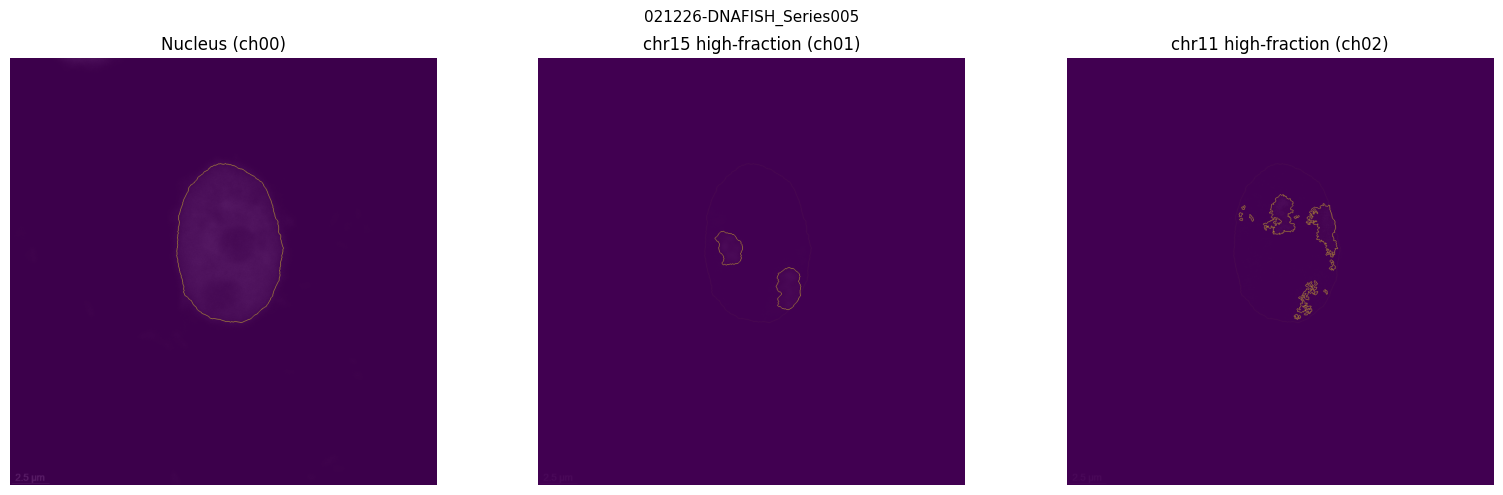

[2/11] 021226-DNAFISH_Series017_ch00_SV.tif


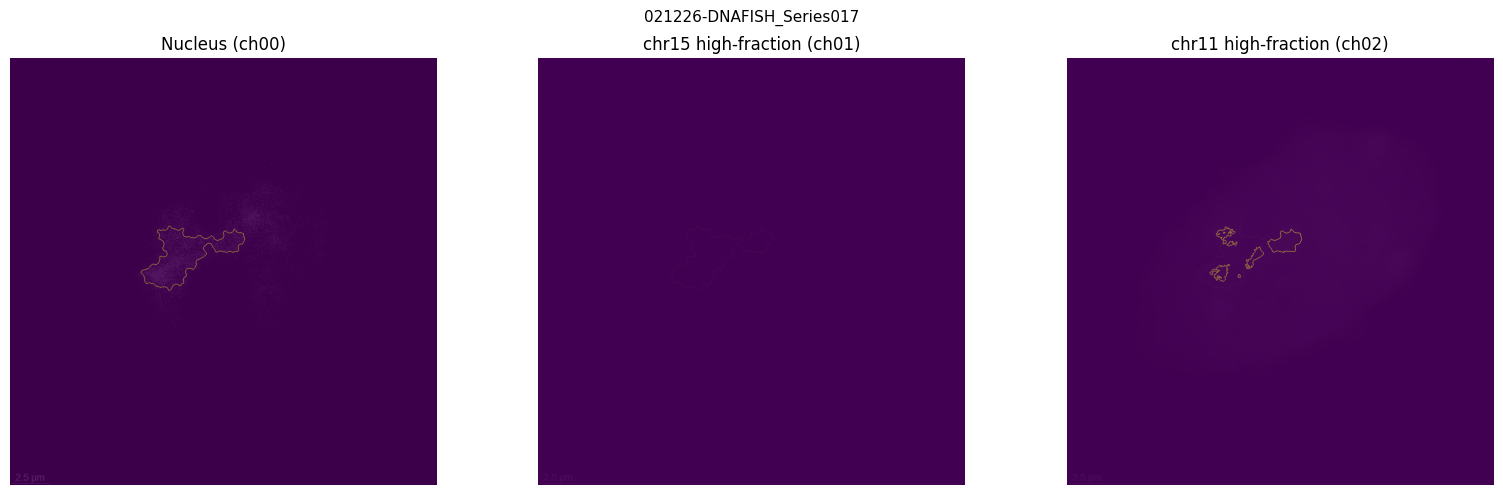

[3/11] 021226-DNAFISH_Series018_ch00_SV.tif


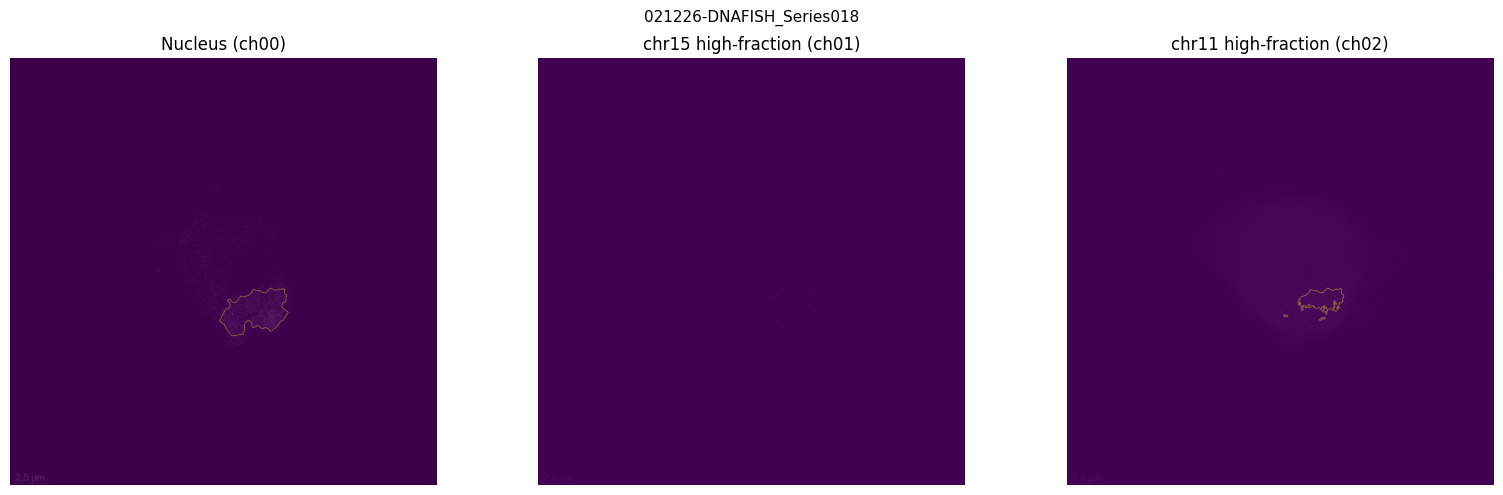

[4/11] 021226-DNAFISH_Series019_ch00_SV.tif
[5/11] 021226-DNAFISH_TileScan 2_P 1 (2)_ch00_SV.tif


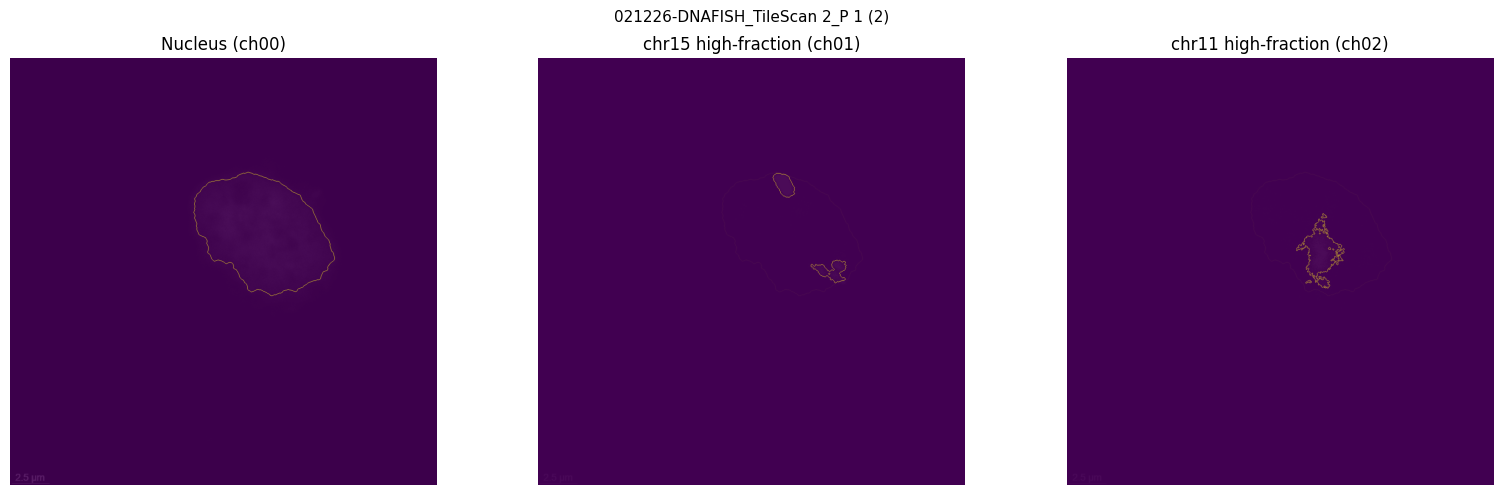

[6/11] 021226-DNAFISH_TileScan 2_P 12_ch00_SV.tif
[7/11] 021226-DNAFISH_TileScan 2_P 13_ch00_SV.tif
[8/11] 021226-DNAFISH_TileScan 2_P 14_ch00_SV.tif
[9/11] 021226-DNAFISH_TileScan 2_P 15_ch00_SV.tif
[10/11] 021226-DNAFISH_TileScan 2_P 16_ch00_SV.tif
[11/11] 021226-DNAFISH_TileScan 2_P 17_ch00_SV.tif

-----------------------------
Processing complete.
Total cells: 11
Successful:  10
Errors:      1
Saved: /home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/mHep_summary.csv
-----------------------------

                                     field_ch00_path  \
0  /home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...   
1  /home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...   
2  /home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...   
3  /home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...   
4  /home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...   

                      field_basename  nucleus_area  nucleus_perimeter  \
0           021226-DNAFISH_Series005       75534.0        1109.543289   
1    

In [6]:
#mHep stage
# ------------------------------------------------------------
# RUN (FULL)
# ------------------------------------------------------------
if __name__ == "__main__":

    folder = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/mHep_chr11-488_chr15-647/"
    out_csv = "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/mHep_summary.csv"
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)

    ch00_files = sorted(glob.glob(os.path.join(folder, "*_ch00_SV.tif")))
    print(f"Found {len(ch00_files)} ch00 files")

    # -----------------------------
    # Nucleus params
    # -----------------------------
    nuc_params = dict(
        sigma=1.0,
        min_nucleus_size=2000,
        hole_area=2000,
        closing_radius=8,
        opening_radius=3,
        use_otsu=True,
    )

    # -----------------------------
    # chr15 parameters (ch01)
    # -----------------------------
    high_params_chr15 = dict(
        sigma_green=1.0,
        sigma_high=1.0,
        high_percentile=70,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=2,
        high_opening_radius=1,
    )

    # -----------------------------
    # chr11 parameters (ch02)
    # -----------------------------
    high_params_chr11 = dict(
        sigma_green=1.0,
        sigma_high=0.5,
        high_percentile=70,
        min_high_size=20,
        high_hole_area=10,
        high_closing_radius=1,
        high_opening_radius=0,
    )

    rows = []
    n_errors = 0
    n_success = 0

    N_plot = 5  # plot first 5 cells only

    for i, ch00 in enumerate(ch00_files, start=1):
        print(f"[{i}/{len(ch00_files)}] {os.path.basename(ch00)}")

        res = process_one_cell_with_highfraction(
            ch00,
            nuc_params=nuc_params,
            high_params_chr15=high_params_chr15,
            high_params_chr11=high_params_chr11,
            show_row_plot=(i <= N_plot),
            p_low=0.5,
            p_high=99.95,     # try 99.95 if still too dim
            alpha_fill=0.25,
        )

        rows.append(res)

        if "error" in res:
            n_errors += 1
        else:
            n_success += 1

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)

    print("\n-----------------------------")
    print("Processing complete.")
    print(f"Total cells: {len(ch00_files)}")
    print(f"Successful:  {n_success}")
    print(f"Errors:      {n_errors}")
    print("Saved:", out_csv)
    print("-----------------------------\n")

    print(df.head())

In [7]:
df

,field_ch00_path,field_basename,nucleus_area,nucleus_perimeter,nucleus_perimeter_over_area,blue_thr,chr15_area,chr15_perimeter,chr15_perimeter_over_area,chr15_high_thr,...,chr15_cluster2_perimeter_over_area,chr15_Rg_cluster1,chr15_Rg_cluster2,chr11_cluster1_area,chr11_cluster2_area,chr11_cluster1_perimeter_over_area,chr11_cluster2_perimeter_over_area,chr11_Rg_cluster1,chr11_Rg_cluster2,error
0,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_Series005,75534.0,1109.543289,0.014689,34.463009,7846.0,561.068109,0.071510,18.457813,...,0.075239,29.168235,25.169608,4148.0,3757.0,0.150498,0.151244,32.838480,29.015808,NaN
1,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_Series017,15339.0,930.537193,0.060665,43.288987,0.0,0.000000,NaN,NaN,...,NaN,NaN,NaN,4870.0,0.0,0.215461,NaN,76.019656,NaN,NaN
2,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_Series018,11631.0,595.553391,0.051204,47.162103,0.0,0.000000,NaN,NaN,...,NaN,NaN,NaN,3887.0,0.0,0.155348,NaN,31.169271,NaN,NaN
3,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_Series019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No nucleus
4,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 1 (2),66897.0,1111.182900,0.016610,16.082738,3885.0,516.038672,0.132828,31.855364,...,0.097728,23.673583,18.815390,7171.0,0.0,0.167710,NaN,40.793250,NaN,NaN
5,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 12,80965.0,1271.952452,0.015710,38.139064,7496.0,493.955411,0.065896,19.064384,...,NaN,40.606401,NaN,7548.0,0.0,0.231922,NaN,73.928362,NaN,NaN
6,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 13,70191.0,1041.342279,0.014836,30.786955,7592.0,693.033621,0.091285,12.898988,...,NaN,85.912845,NaN,11145.0,0.0,0.133630,NaN,77.015006,NaN,NaN
7,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 14,91841.0,1334.035713,0.014525,24.353860,5890.0,660.962554,0.112218,14.490110,...,NaN,64.976124,NaN,10596.0,0.0,0.201985,NaN,89.555647,NaN,NaN
8,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 15,109224.0,1377.876334,0.012615,32.624982,6783.0,707.376767,0.104287,31.549988,...,NaN,64.248622,NaN,8891.0,0.0,0.152622,NaN,119.661072,NaN,NaN
9,/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_c...,021226-DNAFISH_TileScan 2_P 16,92996.0,1377.231673,0.014810,23.434846,8846.0,978.734198,0.110641,11.429757,...,NaN,77.035010,NaN,6734.0,0.0,0.100059,NaN,35.746427,NaN,NaN


In [70]:
df.columns

Index(['field_ch00_path', 'field_basename', 'nucleus_area',
       'nucleus_perimeter', 'nucleus_perimeter_over_area', 'blue_thr',
       'chr15_area', 'chr15_perimeter', 'chr15_perimeter_over_area',
       'chr15_high_thr', 'chr11_area', 'chr11_perimeter',
       'chr11_perimeter_over_area', 'chr11_high_thr',
       'overlap_intersection_px', 'overlap_union_px', 'overlap_jaccard',
       'overlap_over_chr15', 'overlap_over_chr11', 'chr15_cluster_mode',
       'chr11_cluster_mode', 'chr15_cluster_second_frac',
       'chr15_cluster_area_ratio', 'chr15_cluster_centroid_dist',
       'chr11_cluster_second_frac', 'chr11_cluster_area_ratio',
       'chr11_cluster_centroid_dist', 'chr15_nuclear_mean_intensity',
       'chr15_nuclear_sum_intensity', 'chr15_high_pixel_count',
       'chr15_high_sum_intensity', 'chr15_high_mean_intensity',
       'chr15_high_frac_localization', 'chr11_nuclear_mean_intensity',
       'chr11_nuclear_sum_intensity', 'chr11_high_pixel_count',
       'chr11_high_su

# statistic

In [2]:
# ----------------------------
# Load
# ----------------------------
paths = {
    "ES":  "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/ES_summary.csv",
    "DE":  "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/DE_summary.csv",
    "HB":  "/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/HB_summary.csv",
    "iHep":"/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/iHep_summary.csv",
    "mHep":"/home/xiangru.huo-umw/scHiC/scripts/DNA-FISH_chr11Chr15/mHep_summary.csv",
}

dfs = []
for stage, p in paths.items():
    df = pd.read_csv(p)
    df["stage"] = stage
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# optional: drop error rows only
if "error" in all_df.columns:
    all_df = all_df[all_df["error"].isna()].copy()

# ----------------------------
# Derived metrics (keep NaN as NaN)
# ----------------------------
all_df["chr15_perimeter_to_area"] = (
    all_df["chr15_perimeter_over_area"] + all_df["chr15_cluster2_perimeter_over_area"]
)

all_df["chr11_perimeter_to_area"] = (
    all_df["chr11_perimeter_over_area"] + all_df["chr11_cluster2_perimeter_over_area"]
)

all_df["chr15_area_over_nucleus"] = all_df["chr15_area"] / all_df["nucleus_area"]
all_df["chr11_area_over_nucleus"] = all_df["chr11_area"] / all_df["nucleus_area"]

all_df["chr15_Rg_cluster1_norm"] = all_df["chr15_Rg_cluster1"] / np.sqrt(all_df["nucleus_area"])
all_df["chr15_Rg_cluster2_norm"] = all_df["chr15_Rg_cluster2"] / np.sqrt(all_df["nucleus_area"])

all_df["chr11_Rg_cluster1_norm"] = all_df["chr11_Rg_cluster1"] / np.sqrt(all_df["nucleus_area"])
all_df["chr11_Rg_cluster2_norm"] = all_df["chr11_Rg_cluster2"] / np.sqrt(all_df["nucleus_area"])

stage_order = ["ES", "DE", "HB", "iHep", "mHep"]

# Original metrics
plot_df = all_df.copy()

# Combined chr15 Rg values from cluster1 and cluster2
chr15_rg_long = all_df[["stage", "chr15_Rg_cluster1_norm", "chr15_Rg_cluster2_norm"]].melt(
    id_vars="stage",
    value_vars=["chr15_Rg_cluster1_norm", "chr15_Rg_cluster2_norm"],
    value_name="chr15_Rg_cluster_norm"
)[["stage", "chr15_Rg_cluster_norm"]]

# Combined chr11 Rg values from cluster1 and cluster2
chr11_rg_long = all_df[["stage", "chr11_Rg_cluster1_norm", "chr11_Rg_cluster2_norm"]].melt(
    id_vars="stage",
    value_vars=["chr11_Rg_cluster1_norm", "chr11_Rg_cluster2_norm"],
    value_name="chr11_Rg_cluster_norm"
)[["stage", "chr11_Rg_cluster_norm"]]


metrics_row1 = [
    ("chr15_perimeter_to_area", "chr15 P/A", all_df),
    ("chr11_perimeter_to_area", "chr11 P/A", all_df),
    ("chr15_Rg_cluster_norm", "chr15 Rg / sqrt(nucleus area)", chr15_rg_long),
    ("chr11_Rg_cluster_norm", "chr11 Rg / sqrt(nucleus area)", chr11_rg_long),
]

metrics_row2 = [
    ("chr15_area_over_nucleus", "chr15 area / nucleus", all_df),
    ("chr11_area_over_nucleus", "chr11 area / nucleus", all_df),
    ("overlap_over_chr15", "overlap / chr15", all_df),
    ("overlap_over_chr11", "overlap / chr11", all_df),
]

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119

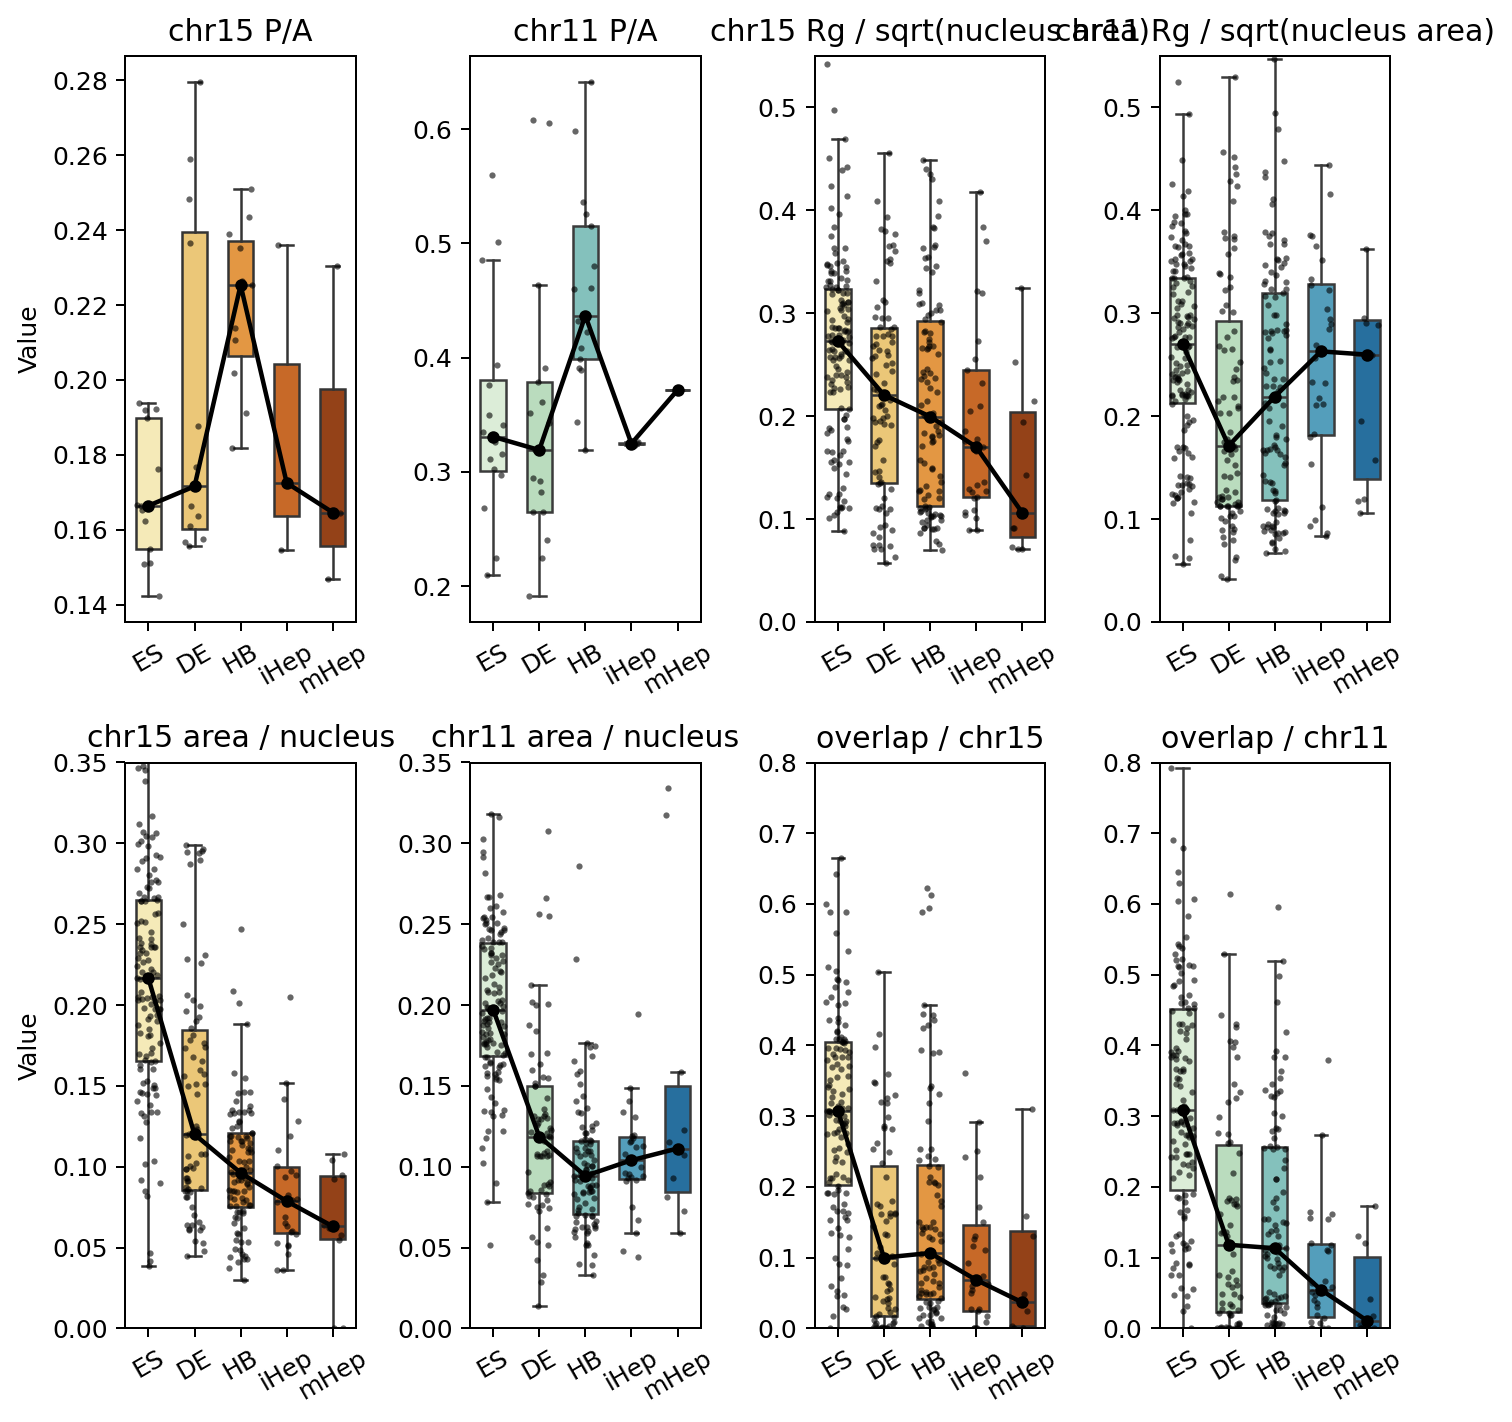

In [6]:
stage_order = ["ES", "DE", "HB", "iHep", "mHep"]

# chr15: light yellow to dark yellow by stage
chr15_palette = dict(zip(
    stage_order,
    sns.color_palette("YlOrBr", n_colors=len(stage_order))
))

# chr11: light cyan to dark cyan by stage
chr11_palette = dict(zip(
    stage_order,
    sns.color_palette("GnBu", n_colors=len(stage_order))
))


def choose_palette(col, title):
    text = f"{col} {title}".lower()

    if "chr15" in text:
        return chr15_palette
    elif "chr11" in text:
        return chr11_palette
    else:
        return "Set2"


def set_yaxis(ax, col, title):
    text = f"{col} {title}".lower()

    if "rg" in text:
        ax.set_ylim(0, 0.55)

    elif "area" in text and "nucleus" in text:
        ax.set_ylim(0, 0.35)

    elif "overlap" in text:
        ax.set_ylim(0, 0.8)


fig, axes = plt.subplots(2, 4, figsize=(8, 8), dpi=180)

for ax, (col, title, data_use) in zip(axes.ravel(), metrics_row1 + metrics_row2):

    palette = choose_palette(col, title)

    sns.boxplot(
        data=data_use,
        x="stage",
        y=col,
        order=stage_order,
        palette=palette,
        width=0.55,
        fliersize=0,
        linewidth=1,
        ax=ax
    )

    sns.stripplot(
        data=data_use,
        x="stage",
        y=col,
        order=stage_order,
        color="black",
        size=2.5,
        alpha=0.6,
        jitter=0.25,
        ax=ax
    )
    
        # -----------------------------
    # Add median line across stages
    # -----------------------------
    median_df = (
        data_use
        .groupby("stage")[col]
        .median()
        .reindex(stage_order)
    )

    ax.plot(
        range(len(stage_order)),
        median_df.values,
        color="black",
        marker="o",
        linewidth=1.8,
        markersize=4,
        zorder=10
    )

    set_yaxis(ax, col, title)

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)

axes[0, 0].set_ylabel("Value")
axes[1, 0].set_ylabel("Value")

plt.tight_layout()
plt.savefig("/home/xiangru.huo-umw/scHiC/scripts/plot/chr11_chr15_metrics_boxplot_with_combined_Rg.pdf", bbox_inches="tight")
plt.show()